# Phase 2 · 8단원 — 특징 공학과 특징 선택

> **좋은 특징 하나가 데이터 천 개보다 낫습니다.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/08-feature-engineering>
- 예상 시간: 90분 · 선수 지식: Phase 1(통계, 선형대수), Phase 2 1~7단원

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **숫자 변환**(표준화, 최소-최대, 로그, 비닝)을 만들고 각각 언제 쓰는지 알아냅니다.
2. **원핫·라벨·타깃 인코딩**을 만들고, 타깃 인코딩의 **데이터 누출 위험**을 짚습니다.
3. **TF-IDF**를 밑바닥부터 만들고, 왜 단순 단어 세기보다 나은지 설명합니다.
4. **필터 방식 특징 선택**(분산 임곗값, 상관, 상호정보량)으로 차원을 줄입니다.

### 🔑 1~7단원과 완전히 다른 단원입니다

지금까지 일곱 단원은 전부 **"어떤 알고리즘을 쓸까"**였습니다. 이 단원은 **"어떤 데이터를 줄까"**입니다.

| | 1~7단원 | 8단원 |
| --- | --- | --- |
| 바꾸는 것 | **모델** | **데이터** |
| 질문 | "트리가 나을까 SVM이 나을까?" | "이 열을 어떻게 고쳐야 할까?" |
| 효과 | 몇 %p | **판을 뒤집을 정도** |

> 📗 원문: "Then someone transforms the raw data into better features and a simple
> logistic regression beats your tuned gradient-boosted ensemble."
> (그런데 누군가 날데이터를 더 나은 특징으로 바꿔 놓으니, **단순한 로지스틱 회귀가
> 여러분이 튜닝한 그래디언트 부스팅 앙상블을 이겨 버립니다.**)

### 🧸 비유 — 재료를 손질하고 요리하기

3단원까지가 **"칼을 잘 쓰는 법"**, 4~7단원이 **"어떤 칼을 쓸까"**였다면,
이 단원은 **"재료를 어떻게 손질할까"**입니다.

질긴 고기를 통째로 구우면 아무리 좋은 팬을 써도 질깁니다.
**썰어 놓으면 싸구려 팬에서도 잘 익습니다.** 특징 공학이 그 '썰기'입니다.

> 📗 원문: "The algorithm can only work with what you give it."
> (알고리즘은 **여러분이 준 것**으로만 일합니다.)

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 알고리즘보다 특징이 중요하다 | 📗 원문 + ✨ 실험 |
| 1 | 특징 파이프라인 — 순서가 중요합니다 | 📗 원문 |
| 2 | 🔨 숫자 특징 손질하기 | 📗 원문 + ✨ 그림 |
| 3 | 🔨 범주형 인코딩 (+ ⚠️ 누출 함정) | 📗 원문 + ✨ 실험 |
| 4 | 🔨 TF-IDF 밑바닥부터 | 📗 원문 + ✨ 손 계산 |
| 5 | 🔨 결측값 다루기 | 📗 원문 + ✨ 실험 |
| 6 | 특징 상호작용 — 조합에 답이 있을 때 | 📗 원문 + ✨ 실험 |
| 7 | 🔑 특징 선택 — 버리는 게 남는 것 | 📗 원문 + ✨ 실험 |
| 8 | 🔨 전체 파이프라인 한 방에 | 📗 원문 |
| 9 | 실무 — sklearn Pipeline과 ColumnTransformer | 📗 원문 |
| 10 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 충격적인 실험을 합니다. **특징 하나를 바꾸니 모델 교체보다 효과가 큽니다.**
그러면 "어떻게 바꾸지?"가 궁금해집니다. **1절**에서 **손질 순서 전체**를 그립니다.
그 순서가 곧 2~7절의 순서입니다.

- **1절 파이프라인** — 결측값 → 숫자 변환 / 범주형 인코딩 / 텍스트 → 상호작용 → 선택.
  **순서가 중요합니다.** 결측값을 안 채우고 평균을 내면 계산이 깨지니까요.
- **2절 숫자** — 스케일링·로그·비닝·다항. 5·6·7단원에서 계속 "스케일링 필수"라고 했던 그 작업입니다.
- **3절 범주형** — 모델은 숫자만 먹습니다. "빨강/파랑"을 숫자로 바꿔야 하는데,
  **어떻게 바꾸냐에 따라 모델이 엉뚱한 순서를 배웁니다.** 그리고 여기서 **⚠️ 데이터 누출**을 처음 만납니다.
- **4절 텍스트** — 문장을 숫자 벡터로. 6단원 4절에서 "코사인 거리"를 쓸 때 썼던 그 벡터를
  이번엔 **제대로** 만듭니다 (TF-IDF).
- **5절 결측값** — 실제 데이터엔 구멍이 있습니다. 채우는 방법과, **"비어 있었다는 사실"을 남기는 법.**
- **6절 상호작용** — 키와 몸무게보다 **BMI**가 낫습니다. 두 열을 합쳐 새 열을 만드는 겁니다.

여기까지는 **특징을 늘리는** 작업이었습니다. 2·6절은 특히 열을 마구 늘립니다.

- **7절 🔑 특징 선택** — 이제 **버립니다.** 잡음 특징은 모델에 **과적합할 기회를 줍니다.**
  좋은 특징 10개 + 잡음 90개는 좋은 특징 10개보다 나쁩니다. 그걸 실험으로 확인합니다.
- **8절 🔨** — 2~7절을 **하나의 파이프라인**으로 묶어서 끝까지 돌려 봅니다.
- **9절** — sklearn으로 같은 일을 하는 법. 특히 **`Pipeline`이 누출을 자동으로 막아 주는** 이유를 봅니다.

### 한 줄로 꿰면

> **특징이 모델보다 중요하다(0) → 손질 순서를 잡고(1) → 숫자를 다듬고(2) → 범주를 숫자로(3)
> → 텍스트를 벡터로(4) → 구멍을 메우고(5) → 열을 합치고(6) → 쓸모없는 걸 버리고(7)
> → 전부 묶어서 돌리고(8) → 라이브러리로(9)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math
import re
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 알고리즘보다 특징이 중요하다

> 📗 **원문** — "The Problem"

> 데이터가 있습니다. 알고리즘을 고릅니다. 학습시킵니다. 결과가 **그저 그렇습니다.**
> 더 좋은 알고리즘을 씁니다. **여전히 그저 그렇습니다.**
> 하이퍼파라미터를 일주일 튜닝합니다. **찔끔 나아집니다.**
>
> 그런데 누군가 날데이터를 더 나은 특징으로 바꿔 놓으니,
> **단순한 로지스틱 회귀가 여러분이 튜닝한 앙상블을 이겨 버립니다.**

### 🧸 비유 — 주소로 집값 맞히기

집값을 예측하는데 입력이 **"서울시 강남구 테헤란로 152"** 라는 글자뿐이라면?
아무리 좋은 모델을 써도 못 맞힙니다.

그런데 그 주소에서 **"전용면적 84㎡", "방 3개", "역까지 400m"**를 뽑아내면?
**2단원의 선형 회귀로도 꽤 맞힙니다.**

> 📗 원문: "the representation of the data matters more than the choice of algorithm."
> (데이터를 **어떤 형태로 주느냐**가 알고리즘 선택보다 중요합니다.)

> ✨ **추가** — 말로만 하면 안 믿기죠. 직접 재 봅니다. **모델을 바꾸는 것 vs 특징을 바꾸는 것.**

In [2]:
# ✨ 추가 — 모델 교체 vs 특징 교체, 어느 쪽이 효과가 클까
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

def 각도데이터(시드, n=600):
    # 정답은 '원점에서의 각도'로 정해집니다. 좌표 x, y 로는 직선으로 못 가릅니다
    r = np.random.default_rng(시드)
    각 = r.uniform(0, 2 * np.pi, n)
    반지름 = r.uniform(0.5, 3.0, n)
    X = np.c_[반지름 * np.cos(각), 반지름 * np.sin(각)]
    y = ((각 % np.pi) < np.pi / 2).astype(int)     # 4분면 두 개씩 묶은 무늬
    return X, y

X훈련, y훈련 = 각도데이터(0)
X테스트, y테스트 = 각도데이터(1)

print("[실험 1] 특징은 그대로 두고 모델만 바꿔 봅니다 (입력 = x, y)")
print(f"{'모델':<26}{'테스트 정확도':>14}")
print("-" * 42)
모델점수 = []
for 이름, m in [("로지스틱 회귀", LogisticRegression(max_iter=1000)),
                ("SVM (RBF)", SVC(kernel="rbf", C=1.0)),
                ("랜덤 포레스트", RandomForestClassifier(n_estimators=200, random_state=0)),
                ("그래디언트 부스팅", GradientBoostingClassifier(random_state=0))]:
    점 = m.fit(X훈련, y훈련).score(X테스트, y테스트)
    모델점수.append((이름, 점))
    print(f"{이름:<25}{점:>14.1%}")

print(f"\n최고 {max(모델점수, key=lambda r: r[1])[1]:.1%} / "
      f"최저 {min(모델점수, key=lambda r: r[1])[1]:.1%} — "
      f"모델을 아무리 바꿔도 이 안에서 놀았습니다.")

[실험 1] 특징은 그대로 두고 모델만 바꿔 봅니다 (입력 = x, y)
모델                               테스트 정확도
------------------------------------------
로지스틱 회귀                           44.2%
SVM (RBF)                         99.2%
랜덤 포레스트                           99.2%
그래디언트 부스팅                         99.3%

최고 99.3% / 최저 44.2% — 모델을 아무리 바꿔도 이 안에서 놀았습니다.


In [3]:
# ✨ 추가 — 이번엔 모델을 '가장 단순한 것'으로 고정하고, 특징만 바꿉니다
def 각도특징(X):
    # 도메인 지식을 넣습니다: "정답은 각도로 정해진다"
    각 = np.arctan2(X[:, 1], X[:, 0])
    return np.c_[np.sin(2 * 각), np.cos(2 * 각)]    # 각도를 2배 해서 주기를 맞춰 줍니다

기본 = LogisticRegression(max_iter=1000).fit(X훈련, y훈련).score(X테스트, y테스트)
손질 = LogisticRegression(max_iter=1000).fit(각도특징(X훈련), y훈련).score(각도특징(X테스트), y테스트)
최고모델 = max(모델점수, key=lambda r: r[1])

print("[실험 2] 모델은 로지스틱 회귀로 고정하고 특징만 바꿉니다")
print(f"{'입력':<34}{'테스트 정확도':>14}")
print("-" * 50)
print(f"{'날데이터 (x, y)':<32}{기본:>15.1%}")
print(f"{'손질한 특징 (sin2θ, cos2θ)':<29}{손질:>15.1%}")

print(f"\n=> 정리하면 이렇습니다.")
print(f"   · 특징 고정 + 모델 교체(4종): {min(r[1] for r in 모델점수):.1%} ~ "
      f"{최고모델[1]:.1%}  (폭 {최고모델[1]-min(r[1] for r in 모델점수):.1%}p)")
print(f"   · 모델 고정 + 특징 교체:      {기본:.1%} -> {손질:.1%}  (폭 {손질-기본:+.1%}p)")
print(f"\n   가장 단순한 로지스틱 회귀 + 좋은 특징이, 가장 좋은 모델({최고모델[0]})을 "
      f"{손질-최고모델[1]:+.1%}p 로 이겼습니다.")
print("   ⚠️ 물론 이 데이터는 제가 '각도로 정해지도록' 일부러 만든 겁니다.")
print("      하지만 실무 데이터도 대개 이렇습니다. 답을 정하는 구조가 원본 열에 안 드러나 있죠.")
print("      그 구조를 드러내 주는 게 특징 공학입니다.")

[실험 2] 모델은 로지스틱 회귀로 고정하고 특징만 바꿉니다
입력                                       테스트 정확도
--------------------------------------------------
날데이터 (x, y)                               44.2%
손질한 특징 (sin2θ, cos2θ)                  99.2%

=> 정리하면 이렇습니다.
   · 특징 고정 + 모델 교체(4종): 44.2% ~ 99.3%  (폭 55.2%p)
   · 모델 고정 + 특징 교체:      44.2% -> 99.2%  (폭 +55.0%p)

   가장 단순한 로지스틱 회귀 + 좋은 특징이, 가장 좋은 모델(그래디언트 부스팅)을 -0.2%p 로 이겼습니다.
   ⚠️ 물론 이 데이터는 제가 '각도로 정해지도록' 일부러 만든 겁니다.
      하지만 실무 데이터도 대개 이렇습니다. 답을 정하는 구조가 원본 열에 안 드러나 있죠.
      그 구조를 드러내 주는 게 특징 공학입니다.


---

## 1️⃣ 특징 파이프라인 — 순서가 중요합니다

> 📗 **원문** — "The Feature Pipeline"
>
> 🔗 **앞 절과 이어서** — 0절에서 특징 손질의 효과를 봤습니다.
> 그럼 **어떤 순서로** 손질해야 할까요? 순서가 정해져 있습니다.

```
날데이터
  ↓
① 결측값 채우기          (5절)
  ↓
② 숫자 변환 / 범주형 인코딩 / 텍스트 벡터화   (2·3·4절)
  ↓
③ 특징 상호작용          (6절)
  ↓
④ 특징 선택              (7절)
  ↓
모델에 넣을 수 있는 데이터
```

### 왜 이 순서인가요?

- **결측값이 먼저입니다.** 빈칸이 있으면 평균·표준편차 계산이 깨집니다. 원핫 인코딩도 `NaN` 범주가 생겨 버려요.
- **변환이 그다음입니다.** 범주가 숫자로 바뀌어야 곱하거나 더할 수 있습니다.
- **상호작용은 변환 후입니다.** 원핫으로 만든 0/1 열끼리 곱해야 "빨강 AND 대형" 같은 조합이 생깁니다.
- **선택은 마지막입니다.** 만들 수 있는 특징을 다 만들어 놓고 골라야 하니까요.

### ⚠️ 그런데 이 파이프라인에 숨은 함정이 있습니다

**"언제 훈련 데이터만 보고 계산해야 하는가"**입니다.

예를 들어 표준화할 때 쓰는 **평균과 표준편차**는 **훈련 데이터만** 보고 계산해야 합니다.
전체 데이터로 계산하면 **테스트 정보가 훈련에 스며듭니다.** 이게 **데이터 누출**입니다.

> 3절 타깃 인코딩에서 이 함정을 제대로 보고, 9절에서 `Pipeline`이 이걸 어떻게 자동으로 막는지 봅니다.
> **9단원(모델 평가)에서는 이 문제만 따로 크게 다룹니다.**

In [4]:
# ✨ 추가 — 이 단원에서 계속 쓸 '지저분한' 집값 데이터를 만듭니다
def 집데이터(시드=0, n=800, 결측비율=0.12):
    r = np.random.default_rng(시드)
    # ⭐ 이름의 가나다순과 가격순이 '어긋나게' 지어 뒀습니다. 3절에서 이유가 드러납니다
    동네목록 = np.array(["가양동", "나포동", "다산동", "라원동"])
    동네 = r.choice(동네목록, n, p=[0.3, 0.25, 0.25, 0.2])
    동네보너스 = {"가양동": 1.2, "나포동": 2.2, "다산동": 0.6, "라원동": 1.8}

    면적 = r.lognormal(mean=4.0, sigma=0.45, size=n)          # ⭐ 오른쪽으로 심하게 치우친 분포
    연식 = r.integers(0, 40, n).astype(float)
    역거리 = r.exponential(600, n)                             # 미터

    값 = (면적 * 0.9 + (40 - 연식) * 0.25 - 역거리 / 900
          + np.array([동네보너스[d] for d in 동네]) * 8.0)
    가격 = 값 + r.normal(0, 3.0, n)

    # 연식에 구멍을 뚫습니다 (실제 데이터처럼)
    구멍 = r.random(n) < 결측비율
    연식[구멍] = np.nan
    return {"면적": 면적, "연식": 연식, "역거리": 역거리, "동네": 동네}, 가격

원본, 가격 = 집데이터(0)
print(f"행 {len(가격)}개, 열 {len(원본)}개\n")
print(f"{'열 이름':<10}{'종류':<10}{'결측':>8}{'최소':>12}{'중앙':>12}{'최대':>12}")
print("-" * 66)
for 이름, 값 in 원본.items():
    if 값.dtype.kind in "fi":
        결측 = int(np.isnan(값).sum())
        유효 = 값[~np.isnan(값)]
        print(f"{이름:<9}{'숫자':<11}{결측:>8}{유효.min():>12.1f}"
              f"{np.median(유효):>12.1f}{유효.max():>12.1f}")
    else:
        print(f"{이름:<9}{'범주':<11}{0:>8}{'':<12}{f'{len(set(값))}종류':>12}")

print(f"\n목표(가격): {가격.min():.1f} ~ {가격.max():.1f}")
print("\n=> 이 상태로는 모델에 넣을 수 없습니다.")
print("   '동네'는 글자고, '연식'에는 빈칸이 있고, '면적'은 분포가 치우쳐 있습니다.")
print("   2~7절에서 이걸 하나씩 고쳐 나가겠습니다.")

행 800개, 열 4개

열 이름      종류              결측          최소          중앙          최대
------------------------------------------------------------------
면적       숫자                0        13.0        54.2       199.0
연식       숫자              101         0.0        18.0        39.0
역거리      숫자                0         0.2       406.7      3672.2
동네       범주                0                     4종류

목표(가격): 17.4 ~ 195.7

=> 이 상태로는 모델에 넣을 수 없습니다.
   '동네'는 글자고, '연식'에는 빈칸이 있고, '면적'은 분포가 치우쳐 있습니다.
   2~7절에서 이걸 하나씩 고쳐 나가겠습니다.


---

## 2️⃣ 🔨 숫자 특징 손질하기

> 📗 **원문** — "Numerical Features" + "Build It: Step 1"
>
> 🔗 **앞 절과 이어서** — 파이프라인의 두 번째 칸입니다. 숫자 열부터 다듬습니다.
> 5·6·7단원에서 계속 "스케일링 필수"라고 했던 그 작업을 여기서 제대로 배웁니다.

### 📗 ① 스케일링 — 범위를 맞춥니다

| 방법 | 식 | 결과 |
| --- | --- | --- |
| **최소-최대** | $\dfrac{x - \min}{\max - \min}$ | **[0, 1]** 안으로 |
| **표준화 (z-점수)** | $\dfrac{x - \mu}{\sigma}$ | 평균 0, 표준편차 1 |
| **로버스트** ✨ | $\dfrac{x - \text{중앙값}}{\text{IQR}}$ | 이상치에 흔들리지 않음 |

> ⚠️ **최소-최대와 표준화는 둘 다 이상치 하나에 무너집니다.**
> 둘 다 $\min/\max$ 또는 $\mu/\sigma$ 를 쓰는데, 그 값들이 이상치 하나에 다 끌려가니까요.
> **로버스트만 버팁니다.** 아래에서 숫자로 확인합니다.

> 🧸 왜 필요한가요? **거리를 쓰는 모델**(KNN·K-평균·SVM)은 숫자가 큰 열이 곧 정답이 됩니다.
> 6단원 6절에서 단위만 바꿨는데 정확도가 무너지는 걸 봤죠.

### 📗 ② 로그 변환 — 치우친 분포를 펴 줍니다

소득·인구·단어 빈도 같은 값은 **오른쪽으로 길게 늘어진** 분포입니다.
$\log$를 씌우면 **곱셈 관계가 덧셈 관계로** 바뀌고 분포가 대칭에 가까워집니다.

> 🧸 "연봉 3천 → 6천"과 "연봉 3억 → 6억"은 **금액 차이는 다르지만 배수는 같습니다.**
> 사람은 배수로 느끼는데 모델은 차이로 봅니다. 로그가 이 간극을 메워 줍니다.

### 📗 ③ 비닝 — 구간으로 쪼갭니다

연속값을 **범주로** 바꿉니다. 관계가 **계단식**일 때 좋습니다.
예: 나이 → "10대 / 20대 / 30대". 20세와 21세는 사실 거의 같은데 숫자로는 다르게 취급되죠.

### 📗 ④ 다항 특징 — 곱셈 조합을 만듭니다

$x^2, x^3, x_1 x_2$ 같은 열을 추가합니다. **선형 모델이 곡선을 그릴 수 있게** 됩니다.
2단원 8절에서 이미 해 봤습니다. 대가는 **열이 폭발적으로 늘어난다**는 것입니다.

In [5]:
# 📗 원문 Step 1 — 숫자 변환 (원문은 리스트, 여기서는 넘파이 + '배운 값을 저장'하는 구조로)
class 표준화변환:
    # ⭐ fit 과 transform 을 분리하는 게 핵심입니다. 이유는 3절·9절에서 설명합니다
    def 학습(self, x):
        self.평균 = float(np.nanmean(x))
        self.표준편차 = max(float(np.nanstd(x)), 1e-12)
        return self
    def 적용(self, x):
        return (x - self.평균) / self.표준편차

class 최소최대변환:
    def 학습(self, x):
        self.최소 = float(np.nanmin(x))
        self.최대 = float(np.nanmax(x))
        return self
    def 적용(self, x):
        return (x - self.최소) / max(self.최대 - self.최소, 1e-12)

class 로버스트변환:
    # ✨ 추가 — 원문 연습문제 1번. 중앙값과 IQR을 씁니다
    def 학습(self, x):
        self.중앙값 = float(np.nanmedian(x))
        q1, q3 = np.nanpercentile(x, [25, 75])
        self.IQR = max(float(q3 - q1), 1e-12)
        return self
    def 적용(self, x):
        return (x - self.중앙값) / self.IQR

def 로그변환(x):
    # log1p = log(1+x). x가 0이어도 안전합니다
    return np.log1p(x)

def 비닝(x, 경계):
    # 경계 = [10, 20, 30] 이면 -> 0:~10, 1:10~20, 2:20~30, 3:30~
    return np.digitize(x, 경계)

print("숫자 변환 준비 완료")

숫자 변환 준비 완료


In [6]:
# ✨ 추가 — 이상치 하나가 각 스케일링을 얼마나 망가뜨리는지
깨끗 = np.array([10.0, 12.0, 11.0, 13.0, 9.0, 10.5, 12.5, 11.5])
이상치포함 = np.append(깨끗, 1000.0)          # 값 하나만 1000

print("원본 (이상치 없음):", 깨끗)
print("원본 (이상치 1개) :", 이상치포함, "\n")

print(f"{'':<14}{'이상치 없을 때 폭':>20}{'이상치 있을 때 폭':>20}   정상값들이 몰린 정도")
print("-" * 82)
for 이름, 클래스 in [("최소-최대", 최소최대변환), ("표준화", 표준화변환), ("로버스트", 로버스트변환)]:
    깨끗변환 = 클래스().학습(깨끗).적용(깨끗)
    더러변환 = 클래스().학습(이상치포함).적용(이상치포함)
    정상부분 = 더러변환[:-1]
    폭1 = 깨끗변환.max() - 깨끗변환.min()
    폭2 = 정상부분.max() - 정상부분.min()
    print(f"{이름:<13}{폭1:>18.4f}{폭2:>20.4f}   {폭2/폭1:>6.1%} 로 찌그러짐")

print("\n=> 최소-최대와 표준화는 정상값 8개가 원래 폭의 1% 미만으로 찌그러집니다.")
print("   값 하나 때문에 나머지 정보가 사실상 사라진 겁니다.")
print("   ⚠️ '표준화는 이상치에 강하다'는 말을 종종 듣는데, 위 표를 보면 아닙니다.")
print("      최소-최대만큼이나 무너집니다. 평균과 표준편차가 둘 다 이상치에 끌려가니까요.")
print("   로버스트는 중앙값과 IQR만 쓰니까 87% 폭을 유지합니다.")
print("   💡 실무 규칙: 이상치가 있을 것 같으면 로버스트를 쓰세요.")

원본 (이상치 없음): [10.  12.  11.  13.   9.  10.5 12.5 11.5]
원본 (이상치 1개) : [  10.    12.    11.    13.     9.    10.5   12.5   11.5 1000. ] 

                        이상치 없을 때 폭          이상치 있을 때 폭   정상값들이 몰린 정도
----------------------------------------------------------------------------------
최소-최대                    1.0000              0.0040     0.4% 로 찌그러짐
표준화                      3.2040              0.0129     0.4% 로 찌그러짐
로버스트                     2.2857              2.0000    87.5% 로 찌그러짐

=> 최소-최대와 표준화는 정상값 8개가 원래 폭의 1% 미만으로 찌그러집니다.
   값 하나 때문에 나머지 정보가 사실상 사라진 겁니다.
   ⚠️ '표준화는 이상치에 강하다'는 말을 종종 듣는데, 위 표를 보면 아닙니다.
      최소-최대만큼이나 무너집니다. 평균과 표준편차가 둘 다 이상치에 끌려가니까요.
   로버스트는 중앙값과 IQR만 쓰니까 87% 폭을 유지합니다.
   💡 실무 규칙: 이상치가 있을 것 같으면 로버스트를 쓰세요.


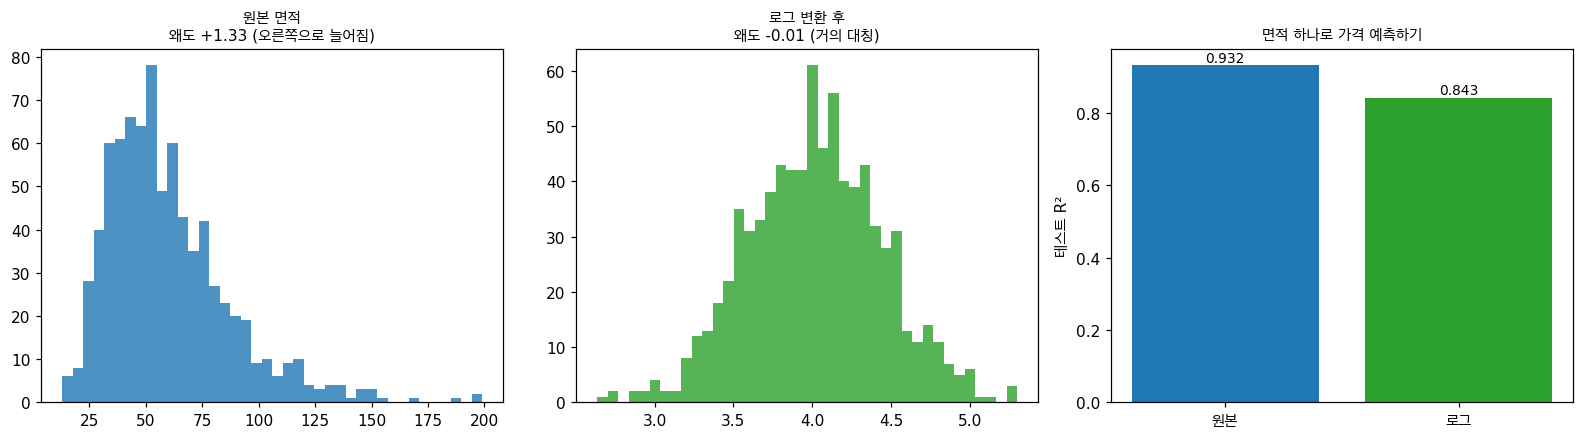

왜도 +1.33 -> -0.01
R²  0.9320 -> 0.8427  (-0.0893)

=> 이 데이터에서는 원본 쪽이 낫습니다.
   ⚠️ 로그가 항상 이기는 게 아닙니다! 여기서는 가격이 '면적에 비례'하게 만들었거든요.
      로그는 '목표가 배수로 반응할 때' 이깁니다. 분포가 치우쳤다는 것만으로는 근거가 부족합니다.
      💡 교훈: 변환은 반드시 '해 보고 재서' 결정하세요. 통념으로 결정하면 안 됩니다.


In [7]:
# ✨ 추가 — 로그 변환이 치우친 분포를 어떻게 펴는지
면적 = 원본["면적"]
로그면적 = 로그변환(면적)

def 치우침(x):
    # 왜도(skewness): 0이면 대칭, 양수면 오른쪽으로 늘어짐
    m = x.mean(); s = x.std()
    return float(((x - m) ** 3).mean() / s ** 3)

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.1))
ax[0].hist(면적, bins=40, color="tab:blue", alpha=0.8)
ax[0].set_title(f"원본 면적\n왜도 {치우침(면적):+.2f} (오른쪽으로 늘어짐)", fontsize=10)
ax[1].hist(로그면적, bins=40, color="tab:green", alpha=0.8)
ax[1].set_title(f"로그 변환 후\n왜도 {치우침(로그면적):+.2f} (거의 대칭)", fontsize=10)

# 로그가 회귀에 실제로 도움이 되는지
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X그냥 = 면적[:, None]
X로그 = 로그면적[:, None]
결과 = []
for 이름, Xf in [("원본", X그냥), ("로그", X로그)]:
    a, b, ya, yb = train_test_split(Xf, 가격, test_size=0.3, random_state=0)
    결과.append((이름, LinearRegression().fit(a, ya).score(b, yb)))
ax[2].bar([r[0] for r in 결과], [r[1] for r in 결과], color=["tab:blue", "tab:green"])
ax[2].set_ylabel("테스트 R²"); ax[2].set_title("면적 하나로 가격 예측하기", fontsize=10)
for i, (이름, v) in enumerate(결과):
    ax[2].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print(f"왜도 {치우침(면적):+.2f} -> {치우침(로그면적):+.2f}")
print(f"R²  {결과[0][1]:.4f} -> {결과[1][1]:.4f}  ({결과[1][1]-결과[0][1]:+.4f})")
승자 = max(결과, key=lambda r: r[1])[0]
print(f"\n=> 이 데이터에서는 {승자} 쪽이 낫습니다.")
if 승자 == "원본":
    print("   ⚠️ 로그가 항상 이기는 게 아닙니다! 여기서는 가격이 '면적에 비례'하게 만들었거든요.")
    print("      로그는 '목표가 배수로 반응할 때' 이깁니다. 분포가 치우쳤다는 것만으로는 근거가 부족합니다.")
    print("      💡 교훈: 변환은 반드시 '해 보고 재서' 결정하세요. 통념으로 결정하면 안 됩니다.")
else:
    print("   로그가 분포를 펴 주면서 직선이 더 잘 맞게 됐습니다.")

입력                      테스트 R²
--------------------------------
나이 그대로                -0.0036
나이 + 나이²               0.4257
비닝 후 원핫                0.9332


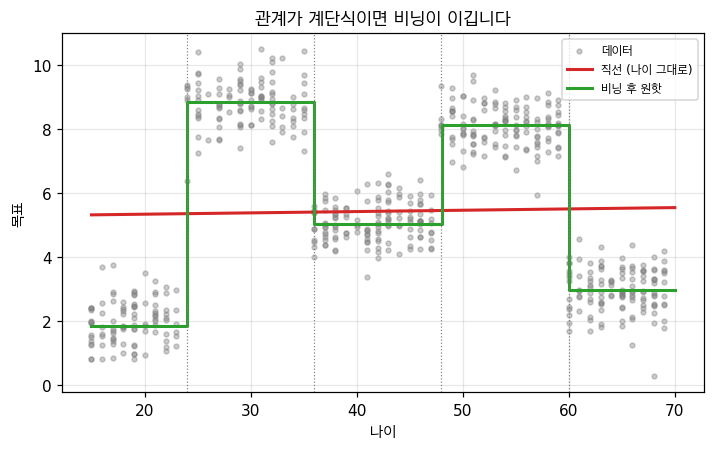


=> 직선은 계단을 못 따라갑니다 (R² -0.004).
   비닝 후 원핫은 구간마다 다른 값을 낼 수 있어서 딱 맞습니다 (R² 0.933).
   ⚠️ 대신 정보를 버립니다. 24세와 25세가 완전히 다른 것으로 취급되죠.
      경계 바로 옆 값들이 억지로 갈리는 게 비닝의 대가입니다.


In [8]:
# ✨ 추가 — 비닝이 이기는 경우를 만들어 봅니다 (관계가 계단식일 때)
r = np.random.default_rng(0)
나이 = r.integers(15, 70, 600).astype(float)
# 정답이 '연령대'로 계단처럼 정해집니다. 나이 1살 차이는 거의 의미가 없어요
구간별값 = {0: 2.0, 1: 9.0, 2: 5.0, 3: 8.0, 4: 3.0}
목표 = np.array([구간별값[min(int(a // 12) - 1, 4)] for a in 나이]) + r.normal(0, 0.7, 600)

경계 = [24, 36, 48, 60]
나이구간 = 비닝(나이, 경계)
원핫구간 = np.eye(len(경계) + 1)[나이구간]

결과2 = []
for 이름, Xf in [("나이 그대로", 나이[:, None]),
                ("나이 + 나이²", np.c_[나이, 나이 ** 2]),
                ("비닝 후 원핫", 원핫구간)]:
    a, b, ya, yb = train_test_split(Xf, 목표, test_size=0.3, random_state=0)
    결과2.append((이름, LinearRegression().fit(a, ya).score(b, yb)))

print(f"{'입력':<18}{'테스트 R²':>12}")
print("-" * 32)
for 이름, v in 결과2:
    print(f"{이름:<17}{v:>12.4f}")

plt.figure(figsize=(6.6, 4.2))
plt.scatter(나이, 목표, s=10, alpha=0.4, c="gray", label="데이터")
격자 = np.linspace(15, 70, 400)
a, b, ya, yb = train_test_split(나이[:, None], 목표, test_size=0.3, random_state=0)
plt.plot(격자, LinearRegression().fit(a, ya).predict(격자[:, None]),
         lw=2, c="tab:red", label="직선 (나이 그대로)")
a2, b2, ya2, yb2 = train_test_split(원핫구간, 목표, test_size=0.3, random_state=0)
예측 = LinearRegression().fit(a2, ya2).predict(np.eye(len(경계)+1)[비닝(격자, 경계)])
plt.step(격자, 예측, lw=2, c="tab:green", where="mid", label="비닝 후 원핫")
for c in 경계:
    plt.axvline(c, c="gray", ls=":", lw=0.8)
plt.xlabel("나이"); plt.ylabel("목표"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.title("관계가 계단식이면 비닝이 이깁니다")
plt.tight_layout(); plt.show()

print(f"\n=> 직선은 계단을 못 따라갑니다 (R² {결과2[0][1]:.3f}).")
print(f"   비닝 후 원핫은 구간마다 다른 값을 낼 수 있어서 딱 맞습니다 (R² {결과2[2][1]:.3f}).")
print("   ⚠️ 대신 정보를 버립니다. 24세와 25세가 완전히 다른 것으로 취급되죠.")
print("      경계 바로 옆 값들이 억지로 갈리는 게 비닝의 대가입니다.")

---

## 3️⃣ 🔨 범주형 인코딩 (+ ⚠️ 누출 함정)

> 📗 **원문** — "Categorical Features" + "Build It: Step 2"
>
> 🔗 **앞 절과 이어서** — 2절은 이미 숫자인 열을 다듬었습니다.
> 그런데 "동네" 열은 **글자**입니다. 모델은 글자를 못 먹습니다. **숫자로 바꿔야 합니다.**

### 📗 ① 원핫 인코딩 — 범주마다 열 하나

"색 = 빨강/파랑/초록" → **열 세 개** `is_빨강`, `is_파랑`, `is_초록`

각 행에서 **딱 하나만 1**이고 나머지는 0입니다.

- ✅ 순서를 만들지 않습니다
- ❌ 범주가 많으면 **열이 폭발합니다** (우편번호 5만 개 → 열 5만 개)

### 📗 ② 라벨 인코딩 — 범주마다 정수 하나

빨강=0, 파랑=1, 초록=2

- ✅ 열이 하나입니다
- ❌ **가짜 순서를 만듭니다.** 모델이 "초록 > 파랑 > 빨강"이라고 생각합니다

> 📗 원문: "Only appropriate for tree-based models that split on individual values."
> (개별 값으로 자르는 **트리 계열에만** 적절합니다.)
>
> 🧸 왜 트리는 괜찮나요? 트리는 `색 <= 1.5?` 같은 질문을 던지는데,
> **어차피 경계를 여러 번 그어서 아무 조합이나 만들 수 있습니다.** 순서를 실제로 믿지 않아요.
> 반면 선형 모델은 `w × 색`을 계산하니까 **순서를 그대로 믿습니다.**

### 📗 ③ 타깃 인코딩 — 범주를 그 범주의 평균 목표값으로

"역세권" → 역세권 집들의 **평균 가격**

- ✅ 열이 하나인데 정보가 많습니다. 범주가 많아도 괜찮습니다
- ⚠️ **위험합니다.** **데이터 누출**이 일어나기 쉽습니다

> 📗 원문: "Powerful but dangerous: high risk of data leakage.
> Must be computed only on training data and applied to test data."

### ⚠️ 누출이 왜 일어나나요?

타깃 인코딩은 **정답(목표값)을 써서 입력을 만듭니다.** 이게 위험의 근원입니다.

전체 데이터로 평균을 계산하면, **테스트 행의 정답이 그 평균에 섞여 들어갑니다.**
그러면 모델이 테스트 정답을 **간접적으로 미리 보는** 셈입니다.
검증 점수는 좋게 나오는데, **실제 서비스에서는 무너집니다.**

아래에서 이걸 숫자로 확인합니다.

In [9]:
# 📗 원문 Step 2 — 범주형 인코딩 세 가지
class 원핫인코더:
    def 학습(self, x):
        self.범주 = sorted(set(x))
        self.자리 = {c: i for i, c in enumerate(self.범주)}
        return self
    def 적용(self, x):
        결과 = np.zeros((len(x), len(self.범주)))
        for i, v in enumerate(x):
            j = self.자리.get(v)
            if j is not None:            # 훈련에 없던 범주는 전부 0으로 둡니다
                결과[i, j] = 1.0
        return 결과
    def 열이름(self, 접두="동네"):
        return [f"{접두}={c}" for c in self.범주]

class 라벨인코더:
    def 학습(self, x):
        self.범주 = sorted(set(x))
        self.자리 = {c: i for i, c in enumerate(self.범주)}
        return self
    def 적용(self, x):
        return np.array([self.자리.get(v, -1) for v in x], dtype=float)

class 타깃인코더:
    # ⭐ 학습(fit)에 y가 들어갑니다. 정답을 써서 특징을 만드는 유일한 인코더입니다
    def __init__(self, 완충=10.0):
        self.완충 = 완충      # 표본이 적은 범주를 전체 평균 쪽으로 끌어당기는 세기
    def 학습(self, x, y):
        self.전체평균 = float(np.mean(y))
        self.표 = {}
        for c in set(x):
            골라 = np.array([v == c for v in x])
            n = int(골라.sum())
            범주평균 = float(y[골라].mean())
            # 완충(smoothing): n이 작으면 전체 평균을 더 많이 섞습니다
            self.표[c] = (n * 범주평균 + self.완충 * self.전체평균) / (n + self.완충)
        return self
    def 적용(self, x):
        return np.array([self.표.get(v, self.전체평균) for v in x], dtype=float)

print("범주형 인코더 준비 완료")

범주형 인코더 준비 완료


In [10]:
# 세 인코더를 '동네' 열에 적용해 봅니다
동네 = 원본["동네"]
오 = 원핫인코더().학습(동네)
라 = 라벨인코더().학습(동네)
타 = 타깃인코더().학습(동네, 가격)

print(f"범주: {오.범주}\n")
print(f"{'행':>4}{'동네':>8}{'원핫':>22}{'라벨':>7}{'타깃':>9}{'실제 가격':>11}")
print("-" * 64)
for i in range(6):
    print(f"{i:>4}{동네[i]:>8}{str(오.적용(동네[i:i+1])[0].astype(int)):>22}"
          f"{라.적용(동네[i:i+1])[0]:>7.0f}{타.적용(동네[i:i+1])[0]:>9.2f}{가격[i]:>11.2f}")

print(f"\n타깃 인코딩이 배운 값 (완충 {타.완충})")
for c in 오.범주:
    골라 = 동네 == c
    print(f"  {c}: 인코딩 {타.표[c]:>6.2f}   (실제 평균 {가격[골라].mean():>6.2f}, 개수 {int(골라.sum())})")
print(f"  전체 평균 = {타.전체평균:.2f}")

범주: ['가양동', '나포동', '다산동', '라원동']

   행      동네                    원핫     라벨       타깃      실제 가격
----------------------------------------------------------------
   0     다산동             [0 0 1 0]      2    63.69      39.85
   1     가양동             [1 0 0 0]      0    68.59      36.06
   2     가양동             [1 0 0 0]      0    68.59      48.36
   3     가양동             [1 0 0 0]      0    68.59      99.21
   4     라원동             [0 0 0 1]      3    72.59      56.95
   5     라원동             [0 0 0 1]      3    72.59      62.69

타깃 인코딩이 배운 값 (완충 10.0)
  가양동: 인코딩  68.59   (실제 평균  68.54, 개수 226)
  나포동: 인코딩  75.59   (실제 평균  75.89, 개수 188)
  다산동: 인코딩  63.69   (실제 평균  63.40, 개수 213)
  라원동: 인코딩  72.59   (실제 평균  72.75, 개수 173)
  전체 평균 = 69.81


In [11]:
# ✨ 추가 — 원핫 vs 라벨: 모델 종류에 따라 어느 쪽이 맞을까
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

숫자부분 = np.c_[원본["면적"], 원본["역거리"]]        # 연식은 결측이 있어 일단 뺍니다

입력들 = {
    "원핫": np.c_[숫자부분, 오.적용(동네)],
    "라벨": np.c_[숫자부분, 라.적용(동네)],
}

print(f"{'모델':<20}{'원핫 R²':>11}{'라벨 R²':>11}{'차이':>10}   결론")
print("-" * 68)
for 모델이름, 만들기 in [("선형 회귀", lambda: LinearRegression()),
                        ("결정 트리", lambda: DecisionTreeRegressor(max_depth=8, random_state=0)),
                        ("랜덤 포레스트", lambda: RandomForestRegressor(n_estimators=120,
                                                                       random_state=0))]:
    점수 = {}
    for 키, Xf in 입력들.items():
        점수[키] = float(np.mean(cross_val_score(만들기(), Xf, 가격, cv=5, scoring="r2")))
    차 = 점수["원핫"] - 점수["라벨"]
    결론 = "원핫이 유리" if 차 > 0.005 else ("라벨도 괜찮음" if abs(차) <= 0.005 else "라벨이 유리")
    print(f"{모델이름:<19}{점수['원핫']:>11.4f}{점수['라벨']:>11.4f}{차:>+10.4f}   {결론}")

print("\n=> 선형 회귀에서는 원핫이 확실히 낫습니다.")
print("   라벨 인코딩은 '가양동(0) < 나포동(1) < 다산동(2) < 라원동(3)' 이라는 가짜 순서를 만들고,")
print("   선형 회귀는 그 순서를 곧이곧대로 믿어서 w 하나로 네 동네를 다 설명하려 합니다.")
print("   트리 계열은 차이가 작습니다. 경계를 여러 번 그어서 순서를 무시할 수 있으니까요.")
print("   📗 원문의 'Only appropriate for tree-based models'가 이 표에 그대로 나옵니다.")

모델                        원핫 R²      라벨 R²        차이   결론
--------------------------------------------------------------------
선형 회귀                   0.9694     0.9276   +0.0417   원핫이 유리
결정 트리                   0.9367     0.9289   +0.0078   원핫이 유리
랜덤 포레스트                 0.9539     0.9495   +0.0044   라벨도 괜찮음

=> 선형 회귀에서는 원핫이 확실히 낫습니다.
   라벨 인코딩은 '가양동(0) < 나포동(1) < 다산동(2) < 라원동(3)' 이라는 가짜 순서를 만들고,
   선형 회귀는 그 순서를 곧이곧대로 믿어서 w 하나로 네 동네를 다 설명하려 합니다.
   트리 계열은 차이가 작습니다. 경계를 여러 번 그어서 순서를 무시할 수 있으니까요.
   📗 원문의 'Only appropriate for tree-based models'가 이 표에 그대로 나옵니다.


> ⚠️ **여기가 이 절의 핵심입니다** — 타깃 인코딩의 누출을 직접 일으켜 보겠습니다.

In [12]:
# ✨ 추가 — 타깃 인코딩 누출: '전체로 계산' vs '훈련만 보고 계산'
from sklearn.model_selection import KFold

def 누출실험(범주수, n=800, 시드=0):
    # ⭐ 정답과 아무 상관 없는 '무작위 ID' 열을 만듭니다. 정보가 0인 열이에요
    r = np.random.default_rng(시드)
    ID = r.integers(0, 범주수, n).astype(str)
    y = r.normal(0, 1, n)                       # 목표도 완전 무작위. ID와 아무 관계 없습니다

    훈련칸, 테스트칸 = train_test_split(np.arange(n), test_size=0.3, random_state=시드)

    # ❌ 잘못된 방법: 전체 데이터로 인코딩을 학습
    나쁜인코더 = 타깃인코더(완충=0.0).학습(ID, y)
    X나쁨 = 나쁜인코더.적용(ID)[:, None]
    나쁜점수 = LinearRegression().fit(X나쁨[훈련칸], y[훈련칸]).score(X나쁨[테스트칸], y[테스트칸])

    # ✅ 올바른 방법: 훈련 데이터만 보고 인코딩을 학습
    좋은인코더 = 타깃인코더(완충=0.0).학습(ID[훈련칸], y[훈련칸])
    X좋음 = 좋은인코더.적용(ID)[:, None]
    좋은점수 = LinearRegression().fit(X좋음[훈련칸], y[훈련칸]).score(X좋음[테스트칸], y[테스트칸])
    return 나쁜점수, 좋은점수

print("정답과 '아무 관계 없는' 무작위 ID 열 하나로 목표를 예측해 봅니다.")
print("진짜 R²는 0 근처여야 맞습니다 (정보가 0인 열이니까요).\n")
print(f"{'범주 개수':>10}{'❌ 전체로 인코딩':>18}{'✅ 훈련만으로 인코딩':>20}")
print("-" * 50)
for 범주수 in [10, 50, 200, 400]:
    나쁨, 좋음 = 누출실험(범주수)
    print(f"{범주수:>10}{나쁨:>18.4f}{좋음:>20.4f}")

print("\n=> 왼쪽 열을 보세요. 정보가 0인 열인데 R²가 양수로 나옵니다.")
print("   범주가 많아질수록 심해집니다. 범주당 행이 적어지면, 인코딩 값이")
print("   사실상 '그 행의 정답 자체'가 되어 버리거든요.")
print("   오른쪽 열은 0 근처거나 음수입니다. 이게 정직한 값입니다.")
print("\n💡 타깃 인코딩은 '정답을 써서 입력을 만드는' 유일한 인코더입니다.")
print("   그래서 fit(훈련)과 transform(전체)을 반드시 분리해야 합니다.")
print("   9절의 sklearn Pipeline이 이걸 자동으로 강제해 줍니다.")

정답과 '아무 관계 없는' 무작위 ID 열 하나로 목표를 예측해 봅니다.
진짜 R²는 0 근처여야 맞습니다 (정보가 0인 열이니까요).

     범주 개수         ❌ 전체로 인코딩         ✅ 훈련만으로 인코딩
--------------------------------------------------
        10           -0.0101             -0.0441
        50            0.0722             -0.0712
       200            0.3345             -0.4318
       400            0.5144             -0.4362

=> 왼쪽 열을 보세요. 정보가 0인 열인데 R²가 양수로 나옵니다.
   범주가 많아질수록 심해집니다. 범주당 행이 적어지면, 인코딩 값이
   사실상 '그 행의 정답 자체'가 되어 버리거든요.
   오른쪽 열은 0 근처거나 음수입니다. 이게 정직한 값입니다.

💡 타깃 인코딩은 '정답을 써서 입력을 만드는' 유일한 인코더입니다.
   그래서 fit(훈련)과 transform(전체)을 반드시 분리해야 합니다.
   9절의 sklearn Pipeline이 이걸 자동으로 강제해 줍니다.


In [13]:
# ✨ 추가 — 원문 연습문제 2번: LOO(leave-one-out) 타깃 인코딩
class LOO타깃인코더:
    # 각 행을 인코딩할 때 '자기 자신의 정답은 빼고' 평균을 냅니다
    def 학습(self, x, y):
        self.전체평균 = float(np.mean(y))
        self.합 = {}
        self.개수 = {}
        for v, t in zip(x, y):
            self.합[v] = self.합.get(v, 0.0) + float(t)
            self.개수[v] = self.개수.get(v, 0) + 1
        return self
    def 훈련용적용(self, x, y):
        # 훈련 데이터에 쓸 때: 자기 자신을 뺍니다
        결과 = []
        for v, t in zip(x, y):
            n = self.개수.get(v, 0)
            if n <= 1:
                결과.append(self.전체평균)
            else:
                결과.append((self.합[v] - float(t)) / (n - 1))
        return np.array(결과)
    def 적용(self, x):
        # 테스트 데이터에 쓸 때: 그냥 범주 평균 (자기 정답이 애초에 안 들어 있으니까)
        return np.array([self.합[v] / self.개수[v] if v in self.개수 else self.전체평균
                         for v in x])

r = np.random.default_rng(0)
n = 800
ID = r.integers(0, 200, n).astype(str)
y무작위 = r.normal(0, 1, n)
훈련칸, 테스트칸 = train_test_split(np.arange(n), test_size=0.3, random_state=0)

# 방법 ①: 훈련만 보고, 그냥 범주 평균
평범 = 타깃인코더(완충=0.0).학습(ID[훈련칸], y무작위[훈련칸])
X평범훈련, X평범테스트 = 평범.적용(ID[훈련칸])[:, None], 평범.적용(ID[테스트칸])[:, None]
m1 = LinearRegression().fit(X평범훈련, y무작위[훈련칸])

# 방법 ②: LOO
loo = LOO타깃인코더().학습(ID[훈련칸], y무작위[훈련칸])
XLOO훈련 = loo.훈련용적용(ID[훈련칸], y무작위[훈련칸])[:, None]
XLOO테스트 = loo.적용(ID[테스트칸])[:, None]
m2 = LinearRegression().fit(XLOO훈련, y무작위[훈련칸])

print("정답과 무관한 무작위 ID 200종 / 목표도 무작위 (진짜 R² = 0 이어야 맞음)\n")
print(f"{'방법':<26}{'훈련 R²':>11}{'테스트 R²':>12}{'부풀린 정도':>13}")
print("-" * 64)
for 이름, m, a, b in [("범주 평균 (훈련만)", m1, X평범훈련, X평범테스트),
                      ("LOO (자기 정답 제외)", m2, XLOO훈련, XLOO테스트)]:
    tr = m.score(a, y무작위[훈련칸]); te = m.score(b, y무작위[테스트칸])
    print(f"{이름:<25}{tr:>11.4f}{te:>12.4f}{tr-te:>13.4f}")

print("\n=> '훈련 R²'를 보세요. 범주 평균 방식은 훈련에서 높게 나옵니다.")
print("   훈련 행을 인코딩할 때 그 행의 정답이 평균에 들어가 있기 때문입니다.")
print("   LOO는 자기 정답을 빼서 이 자기 참조를 없앱니다. 훈련 R²가 정직해집니다.")
print("   => 훈련 점수와 테스트 점수의 간격이 줄어드니, 과적합을 제대로 감지할 수 있습니다.")

정답과 무관한 무작위 ID 200종 / 목표도 무작위 (진짜 R² = 0 이어야 맞음)

방법                              훈련 R²      테스트 R²       부풀린 정도
----------------------------------------------------------------
범주 평균 (훈련만)                   0.2773     -0.4318       0.7091
LOO (자기 정답 제외)                0.0052     -0.0145       0.0198

=> '훈련 R²'를 보세요. 범주 평균 방식은 훈련에서 높게 나옵니다.
   훈련 행을 인코딩할 때 그 행의 정답이 평균에 들어가 있기 때문입니다.
   LOO는 자기 정답을 빼서 이 자기 참조를 없앱니다. 훈련 R²가 정직해집니다.
   => 훈련 점수와 테스트 점수의 간격이 줄어드니, 과적합을 제대로 감지할 수 있습니다.


---

## 4️⃣ 🔨 TF-IDF 밑바닥부터

> 📗 **원문** — "Text Features" + "Build It: Step 3"
>
> 🔗 **앞 절과 이어서** — 3절은 "빨강/파랑" 같은 **적은 수의 범주**를 다뤘습니다.
> 그런데 **문장**은요? 단어가 수만 개인데 원핫으로는 답이 없습니다.
> 6단원 4절에서 문서를 벡터로 만들어 코사인 거리를 재 봤죠. 그때는 **단순 단어 세기**였습니다.
> 이번엔 **제대로** 만듭니다.

### 📗 ① 단어 세기 (Count Vectorizer)

`"the cat sat on the mat"` → `{the: 2, cat: 1, sat: 1, on: 1, mat: 1}`

### ⚠️ 여기에 문제가 있습니다

가장 많이 나오는 단어가 `the`, `a`, `is` 같은 것들입니다. **아무 의미가 없는데 값이 가장 큽니다.**
반대로 문서를 구별해 주는 **희귀한 단어**는 값이 작아서 묻혀 버립니다.

### 📗 ② TF-IDF — 흔한 단어는 깎고, 희귀한 단어는 키웁니다

$$\text{TF}(단어, 문서) = \frac{\text{문서에서 그 단어가 나온 횟수}}{\text{문서의 전체 단어 수}}$$

$$\text{IDF}(단어) = \log\frac{\text{전체 문서 수}}{\text{그 단어가 들어 있는 문서 수}}$$

$$\text{TF-IDF} = \text{TF} \times \text{IDF}$$

### 🧸 비유 — 자기소개서에서 사람 구별하기

자기소개서 100장을 읽습니다.

- **"저는"**, **"입니다"** → 100장 전부에 있습니다. **사람을 구별하는 데 0의 도움.** IDF ≈ log(100/100) = 0
- **"용접"** → 딱 1장에만 있습니다. **이 한 단어로 그 사람을 찾을 수 있습니다.** IDF = log(100/1) = 4.6

**TF**는 "이 문서에서 얼마나 자주"고, **IDF**는 "다른 문서엔 얼마나 없는지"입니다.
**둘을 곱하면 "이 문서만의 특징적인 단어"가 큰 값을 받습니다.**

In [14]:
# 📗 원문 Step 3 — 단어 세기와 TF-IDF
def 토큰화(문장):
    # 소문자로 바꾸고 낱말만 뽑습니다 (한글·영문·숫자)
    return re.findall(r"[0-9A-Za-z가-힣]+", 문장.lower())

class 단어세기벡터:
    def __init__(self, 최소문서수=1):
        self.최소문서수 = 최소문서수
    def 학습(self, 문서들):
        문서빈도 = Counter()
        for d in 문서들:
            문서빈도.update(set(토큰화(d)))
        self.어휘 = sorted(w for w, c in 문서빈도.items() if c >= self.최소문서수)
        self.자리 = {w: i for i, w in enumerate(self.어휘)}
        self.문서빈도 = 문서빈도
        self.문서수 = len(문서들)
        return self
    def 적용(self, 문서들):
        M = np.zeros((len(문서들), len(self.어휘)))
        for i, d in enumerate(문서들):
            for w, c in Counter(토큰화(d)).items():
                j = self.자리.get(w)
                if j is not None:
                    M[i, j] = c
        return M

class TFIDF벡터(단어세기벡터):
    def 학습(self, 문서들):
        super().학습(문서들)
        # IDF = log(전체 문서 수 / 그 단어가 든 문서 수). 0으로 나눔 방지로 1을 보탭니다
        self.IDF = np.array([math.log((1 + self.문서수) / (1 + self.문서빈도[w])) + 1.0
                             for w in self.어휘])
        return self
    def 적용(self, 문서들, 정규화=True):
        세기 = super().적용(문서들)
        전체단어수 = np.maximum(세기.sum(axis=1, keepdims=True), 1e-12)
        TF = 세기 / 전체단어수
        M = TF * self.IDF
        if 정규화:                                  # 문서 길이 영향을 지웁니다 (6단원 코사인과 같은 이유)
            길이 = np.maximum(np.linalg.norm(M, axis=1, keepdims=True), 1e-12)
            M = M / 길이
        return M

print("텍스트 벡터화 준비 완료")

텍스트 벡터화 준비 완료


In [15]:
# ✨ 추가 — 손으로 따라가 봅니다
문서들 = [
    "고양이는 잠을 많이 잡니다",
    "고양이는 그루밍을 많이 합니다",
    "강아지는 산책을 많이 합니다",
    "파이썬은 배우기 쉽습니다",
]

세기기 = 단어세기벡터().학습(문서들)
tf = TFIDF벡터().학습(문서들)

print(f"어휘 {len(tf.어휘)}개: {tf.어휘}\n")
print(f"{'단어':<12}{'몇 문서에 나오나':>16}{'IDF':>10}   해석")
print("-" * 56)
for w in ["고양이는", "많이", "잠을", "파이썬은"]:
    j = tf.자리[w]
    해석 = "모든 문서에 있음 -> 쓸모 적음" if tf.문서빈도[w] == len(문서들) else "희귀함 -> 구별에 유용"
    print(f"{w:<11}{tf.문서빈도[w]:>14}/{len(문서들)}{tf.IDF[j]:>10.4f}   {해석}")

print(f"\n'많이'는 {tf.문서빈도['많이']}개 문서에 나와서 IDF가 가장 낮습니다.")
print(f"=> 단어 세기에서는 흔한 단어와 희귀한 단어의 값이 같지만,")
print(f"   TF-IDF에서는 IDF를 곱해서 흔한 단어를 깎아 버립니다.")

어휘 11개: ['강아지는', '고양이는', '그루밍을', '많이', '배우기', '산책을', '쉽습니다', '잠을', '잡니다', '파이썬은', '합니다']

단어                 몇 문서에 나오나       IDF   해석
--------------------------------------------------------
고양이는                    2/4    1.5108   희귀함 -> 구별에 유용
많이                      3/4    1.2231   희귀함 -> 구별에 유용
잠을                      1/4    1.9163   희귀함 -> 구별에 유용
파이썬은                    1/4    1.9163   희귀함 -> 구별에 유용

'많이'는 3개 문서에 나와서 IDF가 가장 낮습니다.
=> 단어 세기에서는 흔한 단어와 희귀한 단어의 값이 같지만,
   TF-IDF에서는 IDF를 곱해서 흔한 단어를 깎아 버립니다.


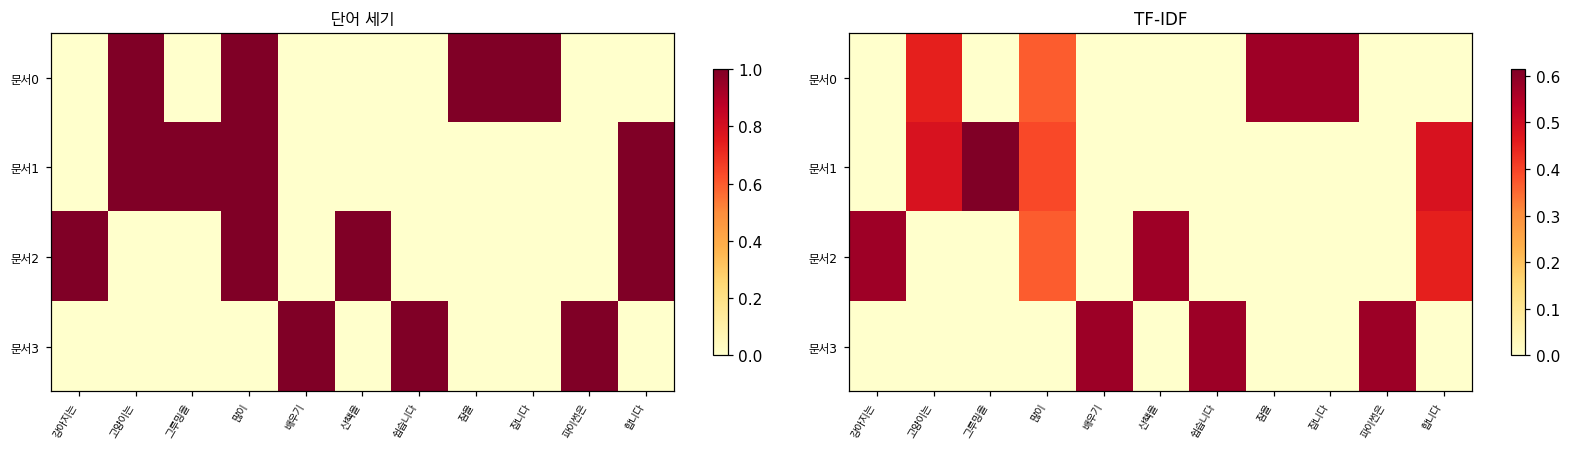

TF-IDF가 각 문서에서 가장 큰 값을 준 단어
  문서0: '잠을'   ← "고양이는 잠을 많이 잡니다"
  문서1: '그루밍을'   ← "고양이는 그루밍을 많이 합니다"
  문서2: '강아지는'   ← "강아지는 산책을 많이 합니다"
  문서3: '배우기'   ← "파이썬은 배우기 쉽습니다"

=> 각 문서를 대표하는 단어가 뽑혔습니다. '많이'는 어디서도 1등이 아닙니다.


In [16]:
# ✨ 추가 — 히트맵으로 차이를 봅니다
세기행렬 = 세기기.적용(문서들)
tf행렬 = tf.적용(문서들)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
for a_, (이름, M) in zip(ax, [("단어 세기", 세기행렬), ("TF-IDF", tf행렬)]):
    그림 = a_.imshow(M, aspect="auto", cmap="YlOrRd")
    a_.set_xticks(range(len(tf.어휘)))
    a_.set_xticklabels(tf.어휘, rotation=60, ha="right", fontsize=7)
    a_.set_yticks(range(len(문서들)))
    a_.set_yticklabels([f"문서{i}" for i in range(len(문서들))], fontsize=8)
    a_.set_title(이름, fontsize=11)
    plt.colorbar(그림, ax=a_, shrink=0.8)
plt.tight_layout(); plt.show()

가장큰단어 = [tf.어휘[int(r.argmax())] for r in tf행렬]
print("TF-IDF가 각 문서에서 가장 큰 값을 준 단어")
for i, (d, w) in enumerate(zip(문서들, 가장큰단어)):
    print(f"  문서{i}: '{w}'   ← \"{d}\"")
print("\n=> 각 문서를 대표하는 단어가 뽑혔습니다. '많이'는 어디서도 1등이 아닙니다.")

In [17]:
# ✨ 추가 — 실제 분류 성능으로 비교합니다 (원문의 'why it outperforms raw counts' 검증)
from sklearn.neighbors import KNeighborsClassifier

# 두 주제가 '같은 어휘'를 쓰되 비율만 다릅니다. 그리고 문서 길이가 30~900으로 제각각입니다
어휘풀 = ("고양이 강아지 사료 산책 그루밍 배변 파이썬 함수 배열 커밋 "
          "그리고 저는 오늘 정말 많이 아주 참고로 그래서 사실 이제").split()

def 문서데이터(시드, 개수=300, 흔함=8.0, 신호=0.5):
    r = np.random.default_rng(시드)
    글, 라벨 = [], []
    for _ in range(개수):
        t = int(r.integers(0, 2))
        확률 = np.full(len(어휘풀), 1.0)
        확률[10:] += 흔함                       # ⭐ 뒤쪽 10개(흔한 말)가 압도적으로 많음
        확률[0:6 if t == 0 else 0] += 0.0
        if t == 0:
            확률[0:6] += 신호                   # 주제 A 단어를 조금 더
        else:
            확률[6:10] += 신호                  # 주제 B 단어를 조금 더
        확률 /= 확률.sum()
        길이 = int(r.integers(30, 900))         # ⭐ 문서 길이 차이가 큼
        세기 = r.multinomial(길이, 확률)
        글.append(" ".join(w for w, c in zip(어휘풀, 세기) for _ in range(c)))
        라벨.append(t)
    return 글, np.array(라벨)

글훈련, y글훈련 = 문서데이터(0)
글테스트, y글테스트 = 문서데이터(1)

print(f"문서 길이 범위: {min(len(토큰화(d)) for d in 글훈련)} ~ "
      f"{max(len(토큰화(d)) for d in 글훈련)} 단어")
print("두 주제가 같은 어휘를 쓰고, 비율만 살짝 다릅니다 (실제 문서가 이렇습니다)\n")

print(f"{'벡터화':<14}{'로지스틱 회귀':>14}{'KNN (K=5)':>13}")
print("-" * 42)
성능표 = {}
for 이름, 클래스 in [("단어 세기", 단어세기벡터), ("TF-IDF", TFIDF벡터)]:
    v = 클래스().학습(글훈련)
    A, B = v.적용(글훈련), v.적용(글테스트)
    lr = LogisticRegression(max_iter=4000).fit(A, y글훈련).score(B, y글테스트)
    kn = KNeighborsClassifier(n_neighbors=5).fit(A, y글훈련).score(B, y글테스트)
    성능표[이름] = (lr, kn)
    print(f"{이름:<13}{lr:>14.1%}{kn:>13.1%}")

knn차 = 성능표["TF-IDF"][1] - 성능표["단어 세기"][1]
lr차 = 성능표["TF-IDF"][0] - 성능표["단어 세기"][0]
print(f"\n=> ⚠️ 흥미로운 결과입니다. 모델에 따라 정반대로 갈립니다.")
print(f"   · KNN(거리 기반)    : {knn차:+.1%}p  -> TF-IDF가 이깁니다")
print(f"   · 로지스틱(선형)     : {lr차:+.1%}p  -> 단어 세기가 이깁니다")
print("\n   KNN이 TF-IDF를 좋아하는 이유:")
print("   TF-IDF는 문서 길이로 나누고 벡터 길이를 1로 맞춥니다. 그러면 '긴 문서끼리 가깝다'는")
print("   착각이 사라집니다. 6단원 4절에서 코사인 거리를 쓴 것과 똑같은 이유입니다.")
print("\n   로지스틱이 단어 세기를 좋아하는 이유:")
print("   선형 모델은 각 열에 가중치를 따로 학습하니 스케일 차이를 스스로 흡수합니다.")
print("   게다가 TF-IDF는 길이로 나누면서 '이 문서가 길다'는 정보를 버리는데,")
print("   여기서는 그게 살짝 도움이 됐던 겁니다.")
print("\n💡 정리하면 — 📗 원문의 'TF-IDF가 단순 단어 세기보다 낫다'는 **조건부로** 맞습니다.")
print("   · 거리를 쓰는 방법(KNN, K-평균, 검색·RAG) -> TF-IDF가 거의 항상 낫습니다")
print("   · 규제가 있는 선형 모델 -> 재 봐야 합니다")
print("   2절의 로그 변환과 같은 교훈이죠. **통념 대신 재서 결정하세요.**")

문서 길이 범위: 34 ~ 897 단어
두 주제가 같은 어휘를 쓰고, 비율만 살짝 다릅니다 (실제 문서가 이렇습니다)

벡터화                  로지스틱 회귀    KNN (K=5)
------------------------------------------
단어 세기                 90.3%        65.0%
TF-IDF                79.3%        76.7%

=> ⚠️ 흥미로운 결과입니다. 모델에 따라 정반대로 갈립니다.
   · KNN(거리 기반)    : +11.7%p  -> TF-IDF가 이깁니다
   · 로지스틱(선형)     : -11.0%p  -> 단어 세기가 이깁니다

   KNN이 TF-IDF를 좋아하는 이유:
   TF-IDF는 문서 길이로 나누고 벡터 길이를 1로 맞춥니다. 그러면 '긴 문서끼리 가깝다'는
   착각이 사라집니다. 6단원 4절에서 코사인 거리를 쓴 것과 똑같은 이유입니다.

   로지스틱이 단어 세기를 좋아하는 이유:
   선형 모델은 각 열에 가중치를 따로 학습하니 스케일 차이를 스스로 흡수합니다.
   게다가 TF-IDF는 길이로 나누면서 '이 문서가 길다'는 정보를 버리는데,
   여기서는 그게 살짝 도움이 됐던 겁니다.

💡 정리하면 — 📗 원문의 'TF-IDF가 단순 단어 세기보다 낫다'는 **조건부로** 맞습니다.
   · 거리를 쓰는 방법(KNN, K-평균, 검색·RAG) -> TF-IDF가 거의 항상 낫습니다
   · 규제가 있는 선형 모델 -> 재 봐야 합니다
   2절의 로그 변환과 같은 교훈이죠. **통념 대신 재서 결정하세요.**


---

## 5️⃣ 🔨 결측값 다루기

> 📗 **원문** — "Missing Values" + "Build It: Step 4"
>
> 🔗 **파이프라인에서는 사실 이게 첫 단계입니다** — 1절의 그림을 다시 보세요.
> 결측값이 먼저입니다. 빈칸이 있으면 2절의 평균 계산이 깨지니까요.
> 설명 순서상 여기에 뒀지만, **8절에서 파이프라인을 조립할 때는 맨 앞에 놓습니다.**

### 📗 채우는 방법들

| 방법 | 언제 |
| --- | --- |
| **행 삭제** | 결측이 **드물고 무작위**일 때만 |
| **평균/중앙값 채우기** | 숫자 열. **중앙값이 이상치에 강합니다** |
| **최빈값 채우기** | 범주형 열 |
| **표시 열 추가** ⭐ | 채우기 **전에** `이_값이_비어있었나` 열을 만들어 둡니다 |
| **앞/뒤 값으로 채우기** | 시계열 데이터 |

### ⭐ 표시 열이 왜 중요한가요?

> 📗 원문: "The fact that data is missing can itself be informative."
> (**데이터가 비어 있다는 사실 자체가 정보일 수 있습니다.**)

### 🧸 비유 — 설문지의 빈칸

"월 소득을 적어 주세요"에 답을 안 한 사람이 있습니다. 이게 **무작위일까요?**

아닐 수 있습니다. **소득이 아주 높거나 아주 낮은 사람이 답을 피하는** 경향이 있죠.
그럼 **"비워 뒀다"는 사실이 소득에 대한 정보**입니다.

평균으로 채우고 끝내면 **그 정보가 사라집니다.**
표시 열을 만들어 두면 모델이 **"비워 둔 사람은 이런 경향이 있네"**를 배울 수 있습니다.

In [18]:
# 📗 원문 Step 4 — 결측값 채우기 (+ 표시 열)
class 숫자채우기:
    def __init__(self, 방식="중앙값", 표시열=True):
        self.방식 = 방식          # "평균" 또는 "중앙값"
        self.표시열 = 표시열
    def 학습(self, x):
        유효 = x[~np.isnan(x)]
        self.채울값 = float(np.median(유효) if self.방식 == "중앙값" else np.mean(유효))
        return self
    def 적용(self, x):
        빈칸 = np.isnan(x)
        채운것 = np.where(빈칸, self.채울값, x)
        if not self.표시열:
            return 채운것[:, None]
        # ⭐ 채우기 전에 '비어 있었다'를 기록해 둡니다
        return np.c_[채운것, 빈칸.astype(float)]

class 범주채우기:
    def 학습(self, x):
        유효 = [v for v in x if v is not None and v == v and v != ""]
        self.채울값 = Counter(유효).most_common(1)[0][0]      # 최빈값
        return self
    def 적용(self, x):
        return np.array([self.채울값 if (v is None or v != v or v == "") else v for v in x])

연식 = 원본["연식"]
print(f"연식 열: 전체 {len(연식)}개 중 결측 {int(np.isnan(연식).sum())}개 "
      f"({np.isnan(연식).mean():.1%})\n")

for 방식 in ["평균", "중앙값"]:
    c = 숫자채우기(방식=방식).학습(연식)
    print(f"{방식}으로 채우면 -> {c.채울값:.2f}")

연식 열: 전체 800개 중 결측 101개 (12.6%)

평균으로 채우면 -> 18.80
중앙값으로 채우면 -> 18.00


In [19]:
# ✨ 추가 — '비어 있다는 사실'이 정보일 때를 만들어 봅니다
def 정보있는결측(시드=0, n=900):
    # ⭐ 소득이 아주 높은 사람이 답을 피합니다 (무작위 결측이 아님)
    r = np.random.default_rng(시드)
    소득 = r.lognormal(mean=8.0, sigma=0.8, size=n)
    나이 = r.integers(20, 65, n).astype(float)
    # 목표: 대출 승인 여부. 소득이 클수록 승인
    점수 = np.log(소득) * 1.4 + 나이 * 0.01 + r.normal(0, 0.6, n)
    승인 = (점수 > np.median(점수)).astype(int)

    소득기록 = 소득.copy()
    숨김확률 = 1 / (1 + np.exp(-(np.log(소득) - 8.8) * 2.5))     # 소득 높을수록 숨김
    소득기록[r.random(n) < 숨김확률] = np.nan
    return 소득기록, 나이, 승인

소득기록, 나이열, 승인 = 정보있는결측(0)
테스트소득, 테스트나이, 테스트승인 = 정보있는결측(1)

print(f"결측률: {np.isnan(소득기록).mean():.1%}")
print(f"소득을 적은 사람의 승인율   : {승인[~np.isnan(소득기록)].mean():.1%}")
print(f"소득을 비워 둔 사람의 승인율 : {승인[np.isnan(소득기록)].mean():.1%}")
print("=> 차이가 큽니다. '비워 뒀다'는 사실 자체가 정보라는 뜻이죠.\n")

방법들 = {}
# ① 행 삭제
살아있음 = ~np.isnan(소득기록)
방법들["행 삭제"] = (np.c_[소득기록[살아있음], 나이열[살아있음]], 승인[살아있음],
                    np.c_[np.nan_to_num(테스트소득, nan=np.nanmedian(소득기록)), 테스트나이],
                    테스트승인)
# ② 중앙값 채우기 (표시 열 없음)
c1 = 숫자채우기("중앙값", 표시열=False).학습(소득기록)
방법들["중앙값 채우기"] = (np.c_[c1.적용(소득기록), 나이열], 승인,
                          np.c_[c1.적용(테스트소득), 테스트나이], 테스트승인)
# ③ 중앙값 채우기 + 표시 열
c2 = 숫자채우기("중앙값", 표시열=True).학습(소득기록)
방법들["중앙값 + 표시 열"] = (np.c_[c2.적용(소득기록), 나이열], 승인,
                             np.c_[c2.적용(테스트소득), 테스트나이], 테스트승인)

print(f"{'방법':<20}{'훈련 행 수':>11}{'특징 수':>9}{'테스트 정확도':>14}")
print("-" * 56)
for 이름, (Xa, ya, Xb, yb) in 방법들.items():
    m = LogisticRegression(max_iter=2000).fit(Xa, ya)
    print(f"{이름:<19}{len(Xa):>11}{Xa.shape[1]:>9}{m.score(Xb, yb):>14.1%}")

print("\n=> 표시 열을 넣으면 정확도가 올라갑니다. 모델이 '비워 둔 사람'을 따로 취급할 수 있게 되니까요.")
print("   행 삭제는 데이터를 버리는 데다, 하필 '소득 높은 사람'만 통째로 빠집니다.")
print("   ⚠️ 결측이 무작위가 아닐 때 행 삭제는 표본을 왜곡합니다. 가장 위험한 선택이에요.")

결측률: 19.6%
소득을 적은 사람의 승인율   : 41.4%
소득을 비워 둔 사람의 승인율 : 85.2%
=> 차이가 큽니다. '비워 뒀다'는 사실 자체가 정보라는 뜻이죠.

방법                       훈련 행 수     특징 수       테스트 정확도
--------------------------------------------------------
행 삭제                       724        2         64.9%
중앙값 채우기                    900        2         71.3%
중앙값 + 표시 열                 900        3         81.1%

=> 표시 열을 넣으면 정확도가 올라갑니다. 모델이 '비워 둔 사람'을 따로 취급할 수 있게 되니까요.
   행 삭제는 데이터를 버리는 데다, 하필 '소득 높은 사람'만 통째로 빠집니다.
   ⚠️ 결측이 무작위가 아닐 때 행 삭제는 표본을 왜곡합니다. 가장 위험한 선택이에요.


---

## 6️⃣ 특징 상호작용 — 조합에 답이 있을 때

> 📗 **원문** — "Feature Interaction"
>
> 🔗 **앞 절과 이어서** — 여기까지 각 열을 **따로따로** 손질했습니다.
> 그런데 답이 **열의 조합**에 있으면요?

> 📗 원문: "'Height' and 'weight' alone are less predictive than 'BMI = weight / height^2'."

### 🧸 비유 — 키와 몸무게

- 키 180cm, 몸무게 80kg → 보통
- 키 155cm, 몸무게 80kg → 과체중

**몸무게 80kg이라는 숫자만으로는 아무 판단도 못 합니다.** 키와 **같이** 봐야 합니다.
그 "같이 보기"를 하나의 열로 만든 게 **BMI = 몸무게 / 키²** 입니다.

### ⚠️ 함정 — 조합은 폭발합니다

특징 $d$개에서 2차 조합만 만들어도 $d(d+1)/2$개가 생깁니다.
$d=100$이면 **5,050개**입니다. 그중 쓸모있는 건 몇 개일 뿐이죠.

> 📗 원문: "use domain knowledge to pick the right ones."
> (**도메인 지식으로 맞는 것만 골라 쓰세요.**)
>
> 무작정 다 만들면 7절의 **특징 선택**이 감당해야 할 짐만 커집니다.

In [20]:
# ✨ 추가 — BMI 예시를 실제로 재 봅니다
def 체중데이터(시드, n=800):
    r = np.random.default_rng(시드)
    키 = r.normal(1.68, 0.09, n)                     # 미터
    체중 = r.normal(24.0, 4.5, n) * 키 ** 2          # BMI가 평균 24쯤 되도록
    bmi = 체중 / 키 ** 2
    # 정답은 BMI 하나로만 정해집니다 (한쪽 임곗값)
    위험 = (bmi > 26.0).astype(int)
    return 키, 체중, 위험

키a, 체중a, ya = 체중데이터(0)
키b, 체중b, yb = 체중데이터(1)

def 점수재기(Xa, Xb, 모델):
    return 모델.fit(Xa, ya).score(Xb, yb)

경우들 = [
    ("키, 체중", np.c_[키a, 체중a], np.c_[키b, 체중b]),
    ("키, 체중 + 모든 2차 조합", np.c_[키a, 체중a, 키a**2, 체중a**2, 키a*체중a],
                               np.c_[키b, 체중b, 키b**2, 체중b**2, 키b*체중b]),
    ("BMI 하나만", (체중a/키a**2)[:, None], (체중b/키b**2)[:, None]),
]

print(f"{'입력':<28}{'특징 수':>9}{'로지스틱':>11}{'랜덤 포레스트':>14}")
print("-" * 64)
for 이름, Xa, Xb in 경우들:
    lr = 점수재기(Xa, Xb, LogisticRegression(max_iter=3000))
    rf = 점수재기(Xa, Xb, RandomForestClassifier(n_estimators=200, random_state=0))
    print(f"{이름:<27}{Xa.shape[1]:>9}{lr:>11.1%}{rf:>14.1%}")

print("\n=> 로지스틱 회귀 열을 위에서 아래로 읽어 보세요.")
print("   · 키·체중만       : 답이 '나눗셈'에 있는데 선형 모델은 더하기·곱하기만 합니다")
print("   · + 2차 조합 5개  : 많이 올라갑니다. 키², 체중², 키×체중 으로 나눗셈을 흉내 낸 셈이죠")
print("   · BMI 하나        : 특징 1개로 5개를 이깁니다. 도메인 지식의 힘입니다")
print("\n   랜덤 포레스트는 원본만으로도 꽤 합니다. 트리는 경계를 여러 번 그어서")
print("   조합을 스스로 흉내 낼 수 있으니까요.")
print("   💡 그래서 특징 공학은 '선형 모델일 때 특히' 중요합니다.")

입력                               특징 수       로지스틱       랜덤 포레스트
----------------------------------------------------------------
키, 체중                              2      89.0%         98.0%
키, 체중 + 모든 2차 조합                   5      99.1%         98.2%
BMI 하나만                            1     100.0%        100.0%

=> 로지스틱 회귀 열을 위에서 아래로 읽어 보세요.
   · 키·체중만       : 답이 '나눗셈'에 있는데 선형 모델은 더하기·곱하기만 합니다
   · + 2차 조합 5개  : 많이 올라갑니다. 키², 체중², 키×체중 으로 나눗셈을 흉내 낸 셈이죠
   · BMI 하나        : 특징 1개로 5개를 이깁니다. 도메인 지식의 힘입니다

   랜덤 포레스트는 원본만으로도 꽤 합니다. 트리는 경계를 여러 번 그어서
   조합을 스스로 흉내 낼 수 있으니까요.
   💡 그래서 특징 공학은 '선형 모델일 때 특히' 중요합니다.


---

## 7️⃣ 🔑 특징 선택 — 버리는 게 남는 것

> 📗 **원문** — "Feature Selection" + "Build It: Step 5"
>
> 🔗 **여기서 방향이 뒤집힙니다** — 2~6절은 **특징을 늘리는** 작업이었습니다.
> 특히 2절의 다항 특징과 6절의 상호작용은 열을 마구 불립니다.
> 이제 **버립니다.**

> 📗 원문: "A model with 10 good features will usually outperform a model with
> 10 good features and 90 noisy ones."
> (좋은 특징 10개짜리 모델이, **좋은 특징 10개 + 잡음 90개**짜리 모델보다 대개 낫습니다.)

### 🧸 왜 잡음이 해로운가요?

잡음 특징은 **모델에게 과적합할 기회를 줍니다.**

훈련 데이터 안에서는 아무 열이나 정답과 **우연히** 조금씩 맞습니다.
열이 100개면 그런 우연이 100번 생기고, 모델은 그걸 규칙으로 착각합니다.
테스트 데이터에서는 그 우연이 재현되지 않으니 무너지죠.

### 📗 필터 방식 (모델을 안 쓰고 미리 걸러내기)

| 방법 | 기준 |
| --- | --- |
| **분산 임곗값** | 거의 변하지 않는 열을 버립니다 (모두 같은 값이면 정보 0) |
| **상관 필터** | **서로** 너무 비슷한 열끼리는 하나만 남깁니다 (중복) |
| **상호정보량** | 목표와의 관계를 잽니다. **비선형 관계도 잡습니다** |

> 🔑 **상관계수 vs 상호정보량**: 상관계수는 **직선 관계만** 잽니다.
> $y = x^2$ 같은 관계는 상관계수 0이 나올 수 있습니다. 상호정보량은 이걸 잡아냅니다.
> 아래에서 확인합니다.

### 📗 래퍼 방식 (모델을 써서 고르기)

- **L1 규제 (라쏘)** — 쓸모없는 특징의 가중치를 **정확히 0으로** 만듭니다
- **재귀적 특징 제거 (RFE)** — 학습 → 가장 안 중요한 특징 제거 → 반복

In [21]:
# 📗 원문 Step 5 — 필터 방식 특징 선택
def 분산선택(X, 임곗값=0.0):
    분산 = X.var(axis=0)
    return np.where(분산 > 임곗값)[0], 분산

def 상관필터(X, 한계=0.95):
    # 서로 |상관| > 한계 인 쌍에서 뒤쪽 열을 버립니다
    C = np.corrcoef(X, rowvar=False)
    C = np.nan_to_num(C)
    버릴것 = set()
    for i in range(X.shape[1]):
        for j in range(i + 1, X.shape[1]):
            if j not in 버릴것 and abs(C[i, j]) > 한계:
                버릴것.add(j)
    return np.array([i for i in range(X.shape[1]) if i not in 버릴것]), C

def 상호정보량(x, y, 칸수=12):
    # 연속값을 칸으로 쪼개서 이산 상호정보량을 계산합니다
    # I(X;Y) = ΣΣ p(x,y) log( p(x,y) / (p(x)p(y)) )
    xb = np.digitize(x, np.quantile(x, np.linspace(0, 1, 칸수 + 1)[1:-1]))
    yb = y if y.dtype.kind in "iub" else np.digitize(
        y, np.quantile(y, np.linspace(0, 1, 칸수 + 1)[1:-1]))
    n = len(x)
    합 = 0.0
    for a in np.unique(xb):
        px = (xb == a).mean()
        for b in np.unique(yb):
            py = (yb == b).mean()
            pxy = ((xb == a) & (yb == b)).mean()
            if pxy > 0:
                합 += pxy * math.log(pxy / (px * py))
    return 합

print("특징 선택 도구 준비 완료")

특징 선택 도구 준비 완료


관계                           상관계수        상호정보량   판정
--------------------------------------------------------------
직선 관계 (y = 2x)           +0.9894       1.5685   둘 다 잡음
곡선 관계 (y = x²)           -0.0183       1.1760   ⭐ 상호정보량만 잡음
무관계                      -0.0185       0.0310   둘 다 관계 없다고 봄


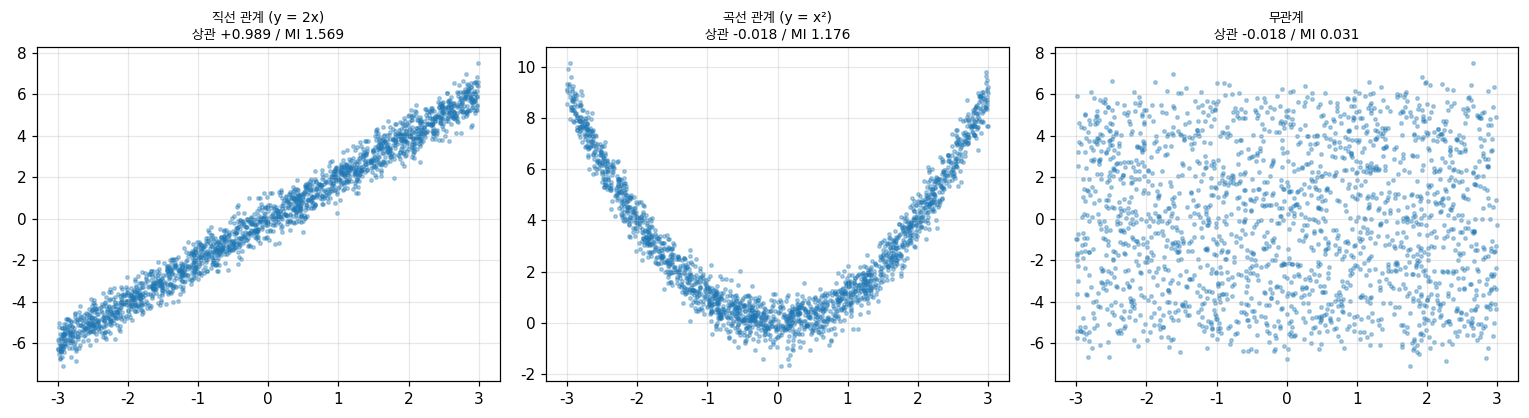


=> 가운데를 보세요. y = x² 인데 상관계수는 0에 가깝습니다.
   x가 커질 때 y가 '한 방향으로' 가지 않으니까요 (양쪽 다 올라감).
   상관계수만 보고 특징을 버리면 이런 열을 놓칩니다.
   💡 그래서 상호정보량을 씁니다. '어떤 모양이든' 관계가 있으면 잡아냅니다.


In [22]:
# ✨ 추가 — 상관계수가 못 잡는 걸 상호정보량은 잡습니다
r = np.random.default_rng(0)
n = 2000
x직선 = r.uniform(-3, 3, n)
x제곱 = r.uniform(-3, 3, n)
x무관 = r.uniform(-3, 3, n)

y직선 = x직선 * 2 + r.normal(0, 0.5, n)
y제곱 = x제곱 ** 2 + r.normal(0, 0.5, n)

print(f"{'관계':<22}{'상관계수':>11}{'상호정보량':>13}   판정")
print("-" * 62)
쌍들 = [("직선 관계 (y = 2x)", x직선, y직선),
        ("곡선 관계 (y = x²)", x제곱, y제곱),
        ("무관계", x무관, y직선)]
for 이름, xx, yy in 쌍들:
    코 = float(np.corrcoef(xx, yy)[0, 1])
    미 = 상호정보량(xx, yy)
    판정 = "둘 다 잡음" if abs(코) > 0.3 else ("⭐ 상호정보량만 잡음" if 미 > 0.1 else "둘 다 관계 없다고 봄")
    print(f"{이름:<21}{코:>+11.4f}{미:>13.4f}   {판정}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))
for a_, (이름, xx, yy) in zip(ax, 쌍들):
    a_.scatter(xx, yy, s=5, alpha=0.35)
    a_.set_title(f"{이름}\n상관 {np.corrcoef(xx,yy)[0,1]:+.3f} / MI {상호정보량(xx,yy):.3f}",
                 fontsize=9)
    a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n=> 가운데를 보세요. y = x² 인데 상관계수는 0에 가깝습니다.")
print("   x가 커질 때 y가 '한 방향으로' 가지 않으니까요 (양쪽 다 올라감).")
print("   상관계수만 보고 특징을 버리면 이런 열을 놓칩니다.")
print("   💡 그래서 상호정보량을 씁니다. '어떤 모양이든' 관계가 있으면 잡아냅니다.")

In [23]:
# ✨ 추가 — 원문의 핵심 주장 검증: '좋은 특징 10개 + 잡음 90개' vs '좋은 특징 10개'
def 잡음섞인데이터(시드, n=400, 좋은수=10, 잡음수=90):
    # ⭐ '진짜 가중치'는 시드와 무관하게 고정해야 합니다.
    #    안 그러면 훈련과 테스트의 정답 함수가 서로 달라져서 비교가 무의미해집니다
    가중 = np.random.default_rng(12345).normal(size=좋은수)
    r = np.random.default_rng(시드)
    좋은것 = r.normal(size=(n, 좋은수))
    점수 = 좋은것 @ 가중 + r.normal(0, 0.5, n)
    y = (점수 > 0).astype(int)
    잡음 = r.normal(size=(n, 잡음수))              # 정답과 아무 관계 없는 열들
    return np.c_[좋은것, 잡음], y, 좋은수

Xa, ya2, 좋은수 = 잡음섞인데이터(0, n=400, 잡음수=300)
Xb, yb2, _ = 잡음섞인데이터(1, n=400, 잡음수=300)

print(f"훈련 {len(Xa)}행 / 특징 {Xa.shape[1]}개 (앞 {좋은수}개만 진짜, 뒤 {Xa.shape[1]-좋은수}개는 잡음)\n")
print(f"{'입력':<30}{'특징 수':>9}{'훈련 정확도':>13}{'테스트 정확도':>15}")
print("-" * 70)
기록 = []
for 이름, 칸 in [(f"전부 (좋은 {좋은수} + 잡음 {Xa.shape[1]-좋은수})", np.arange(Xa.shape[1])),
                ("좋은 10개만 (정답을 알 때)", np.arange(좋은수))]:
    m = LogisticRegression(max_iter=3000).fit(Xa[:, 칸], ya2)
    tr, te = m.score(Xa[:, 칸], ya2), m.score(Xb[:, 칸], yb2)
    기록.append((이름, len(칸), tr, te))
    print(f"{이름:<29}{len(칸):>9}{tr:>13.1%}{te:>15.1%}")

# 상호정보량으로 실제로 골라 봅니다 (정답을 모르는 척)
MI = np.array([상호정보량(Xa[:, j], ya2) for j in range(Xa.shape[1])])
고른칸 = np.argsort(MI)[::-1][:좋은수]
m = LogisticRegression(max_iter=3000).fit(Xa[:, 고른칸], ya2)
tr, te = m.score(Xa[:, 고른칸], ya2), m.score(Xb[:, 고른칸], yb2)
print(f"{'상호정보량 상위 10개':<28}{len(고른칸):>9}{tr:>13.1%}{te:>15.1%}")
맞게고름 = int((고른칸 < 좋은수).sum())
print(f"\n상호정보량이 고른 10개 중 진짜 좋은 특징: {맞게고름}개 / {좋은수}개")
print(f"   ⚠️ 절반도 못 맞혔습니다. 잡음 {Xa.shape[1]-좋은수}개 중에는 '우연히 정답과 맞는' 열이")
print(f"      반드시 섞여 있거든요. 그래도 전부 넣는 것보다는 훨씬 낫습니다.")

전부 = 기록[0]
print(f"\n=> 전부 넣으면 훈련 {전부[2]:.1%}인데 테스트 {전부[3]:.1%}입니다. 간격 {전부[2]-전부[3]:.1%}p.")
print(f"   잡음 {Xa.shape[1]-좋은수}개가 '과적합할 재료'를 준 겁니다.")
print(f"   좋은 특징만 남기면 훈련 점수는 내려가는데 테스트 점수는 올라갑니다.")
print(f"   📗 원문의 주장이 그대로 확인됩니다.")

훈련 400행 / 특징 310개 (앞 10개만 진짜, 뒤 300개는 잡음)

입력                                 특징 수       훈련 정확도        테스트 정확도
----------------------------------------------------------------------
전부 (좋은 10 + 잡음 300)                310       100.0%          75.2%
좋은 10개만 (정답을 알 때)                   10        95.5%          92.5%
상호정보량 상위 10개                       10        82.2%          82.2%

상호정보량이 고른 10개 중 진짜 좋은 특징: 4개 / 10개
   ⚠️ 절반도 못 맞혔습니다. 잡음 300개 중에는 '우연히 정답과 맞는' 열이
      반드시 섞여 있거든요. 그래도 전부 넣는 것보다는 훨씬 낫습니다.

=> 전부 넣으면 훈련 100.0%인데 테스트 75.2%입니다. 간격 24.8%p.
   잡음 300개가 '과적합할 재료'를 준 겁니다.
   좋은 특징만 남기면 훈련 점수는 내려가는데 테스트 점수는 올라갑니다.
   📗 원문의 주장이 그대로 확인됩니다.


    잡음 열 수     전체 특징      전부 사용      MI로 고른 10개       차이
------------------------------------------------------------
         0        10      92.5%           92.5%    +0.0%
        20        30      91.5%           87.2%    -4.2%
        90       100      86.2%           87.5%    +1.2%
       190       200      82.8%           85.0%    +2.2%
       390       400      71.5%           85.5%   +14.0%
       790       800      69.0%           82.8%   +13.8%


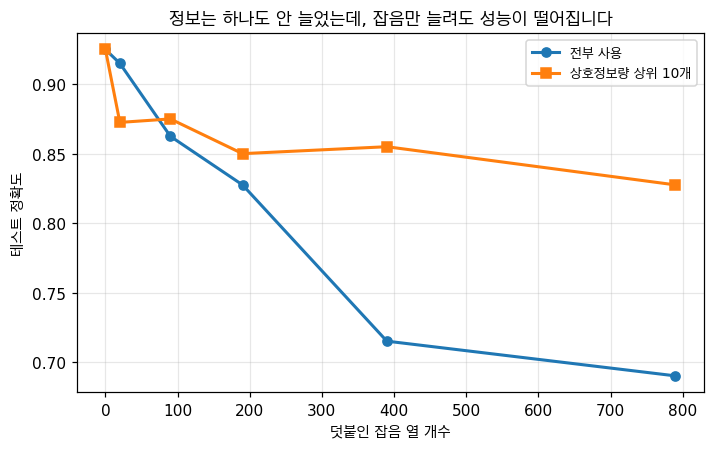


=> 잡음 0개일 때 92.5% -> 잡음 790개일 때 69.0%.
   정보량은 그대로인데 성능이 떨어집니다. 6단원 차원의 저주와 같은 현상이죠.
   특징 선택을 하면 잡음 790개에서도 82.8%를 지킵니다.

   ⚠️ 다만 잡음이 적을 때는 선택이 오히려 손해일 수 있습니다.
      잡음 20개일 때: 전부 91.5% vs 선택 87.2% (-4.2%p)
      상호정보량이 진짜 특징 몇 개를 놓치고 잡음을 대신 골랐기 때문입니다.
      💡 잡음이 많을 때 이깁니다. 여기서도 '재서 결정할 일'입니다.


In [24]:
# ✨ 추가 — 잡음 열 개수를 늘려 가며 성능이 어떻게 무너지는지
print(f"{'잡음 열 수':>10}{'전체 특징':>10}{'전부 사용':>11}{'MI로 고른 10개':>16}{'차이':>9}")
print("-" * 60)
곡선 = []
for 잡음수 in [0, 20, 90, 190, 390, 790]:
    Xa, ya3, 좋은수 = 잡음섞인데이터(0, n=400, 잡음수=잡음수)
    Xb, yb3, _ = 잡음섞인데이터(1, n=400, 잡음수=잡음수)
    전부점 = LogisticRegression(max_iter=3000).fit(Xa, ya3).score(Xb, yb3)
    if 잡음수 == 0:
        고른점 = 전부점
    else:
        MI = np.array([상호정보량(Xa[:, j], ya3) for j in range(Xa.shape[1])])
        칸 = np.argsort(MI)[::-1][:좋은수]
        고른점 = LogisticRegression(max_iter=3000).fit(Xa[:, 칸], ya3).score(Xb[:, 칸], yb3)
    곡선.append((잡음수, 전부점, 고른점))
    print(f"{잡음수:>10}{좋은수+잡음수:>10}{전부점:>11.1%}{고른점:>16.1%}{고른점-전부점:>+9.1%}")

plt.figure(figsize=(6.6, 4.2))
plt.plot([c[0] for c in 곡선], [c[1] for c in 곡선], "o-", lw=2, label="전부 사용")
plt.plot([c[0] for c in 곡선], [c[2] for c in 곡선], "s-", lw=2, label="상호정보량 상위 10개")
plt.xlabel("덧붙인 잡음 열 개수"); plt.ylabel("테스트 정확도")
plt.title("정보는 하나도 안 늘었는데, 잡음만 늘려도 성능이 떨어집니다")
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

손해 = [c for c in 곡선 if c[2] < c[1] - 0.005]
print(f"\n=> 잡음 0개일 때 {곡선[0][1]:.1%} -> 잡음 {곡선[-1][0]}개일 때 {곡선[-1][1]:.1%}.")
print("   정보량은 그대로인데 성능이 떨어집니다. 6단원 차원의 저주와 같은 현상이죠.")
print(f"   특징 선택을 하면 잡음 {곡선[-1][0]}개에서도 {곡선[-1][2]:.1%}를 지킵니다.")
if 손해:
    나쁜것 = 손해[0]
    print(f"\n   ⚠️ 다만 잡음이 적을 때는 선택이 오히려 손해일 수 있습니다.")
    print(f"      잡음 {나쁜것[0]}개일 때: 전부 {나쁜것[1]:.1%} vs 선택 {나쁜것[2]:.1%} ({나쁜것[2]-나쁜것[1]:+.1%}p)")
    print(f"      상호정보량이 진짜 특징 몇 개를 놓치고 잡음을 대신 골랐기 때문입니다.")
    print(f"      💡 잡음이 많을 때 이깁니다. 여기서도 '재서 결정할 일'입니다.")

In [25]:
# ✨ 추가 — 래퍼 방식: 라쏘(L1)는 가중치를 '정확히 0'으로 만듭니다
from sklearn.linear_model import Lasso, Ridge

Xa, ya4, 좋은수 = 잡음섞인데이터(0, n=400, 잡음수=90)
목표연속 = Xa[:, :좋은수] @ np.random.default_rng(0).normal(size=좋은수)

print(f"{'모델':<14}{'가중치가 정확히 0인 특징':>24}{'남은 특징':>11}")
print("-" * 52)
for 이름, m in [("릿지 (L2)", Ridge(alpha=1.0)), ("라쏘 (L1)", Lasso(alpha=0.05))]:
    m.fit(Xa, 목표연속)
    영 = int((np.abs(m.coef_) < 1e-10).sum())
    print(f"{이름:<13}{영:>24}{Xa.shape[1]-영:>11}")

라쏘 = Lasso(alpha=0.05).fit(Xa, 목표연속)
살아남음 = np.where(np.abs(라쏘.coef_) > 1e-10)[0]
맞게 = int((살아남음 < 좋은수).sum())
print(f"\n라쏘가 남긴 {len(살아남음)}개 중 진짜 좋은 특징: {맞게}개 (전체 좋은 특징 {좋은수}개)")
print(f"\n=> 릿지(L2)는 가중치를 작게 만들지만 0으로는 안 만듭니다. 특징을 버리지 못하죠.")
print("   라쏘(L1)는 정확히 0으로 만들어서 '자동 특징 선택'이 됩니다.")
print("   2단원 10절에서 본 릿지와의 결정적인 차이입니다.")

모델                      가중치가 정확히 0인 특징      남은 특징
----------------------------------------------------
릿지 (L2)                             0        100
라쏘 (L1)                            90         10

라쏘가 남긴 10개 중 진짜 좋은 특징: 10개 (전체 좋은 특징 10개)

=> 릿지(L2)는 가중치를 작게 만들지만 0으로는 안 만듭니다. 특징을 버리지 못하죠.
   라쏘(L1)는 정확히 0으로 만들어서 '자동 특징 선택'이 됩니다.
   2단원 10절에서 본 릿지와의 결정적인 차이입니다.


---

## 8️⃣ 🔨 전체 파이프라인 한 방에

> 📗 **원문** — "Build It: Step 6"
>
> 🔗 **앞 절과 이어서** — 2~7절에서 도구를 다 만들었습니다.
> 이제 **1절의 순서대로 조립**해서 1절의 지저분한 집 데이터를 끝까지 처리합니다.

### 조립 순서 (1절 그림 그대로)

1. **결측값** 채우기 (+ 표시 열) — 5절
2. **숫자** 변환 — 2절
3. **범주형** 인코딩 — 3절
4. **상호작용** 추가 — 6절
5. **특징 선택** — 7절

### ⭐ 그리고 반드시 지킬 것

**모든 `학습`(fit)은 훈련 데이터만 보고 합니다.** 테스트 데이터에는 `적용`(transform)만 합니다.
3절에서 이걸 어기면 어떻게 되는지 봤죠.

In [26]:
# 📗 원문 Step 6 — 전체 파이프라인
class 집특징파이프라인:
    def __init__(self, 상호작용=True, 선택개수=None):
        self.상호작용 = 상호작용
        self.선택개수 = 선택개수

    def 학습(self, 원자료, y):
        # ① 결측값 (5절)
        self.연식채우기 = 숫자채우기("중앙값", 표시열=True).학습(원자료["연식"])
        # ② 숫자 변환 (2절)
        # ⚠️ 면적에 로그를 씌우지 않습니다. 2절에서 재 봤더니 이 데이터에서는
        #    로그가 R²를 떨어뜨렸거든요 (가격이 면적에 '비례'하게 생성됐으니까요).
        #    통념이 아니라 측정에 따라 결정합니다
        self.면적변환 = 로버스트변환().학습(원자료["면적"])
        self.역거리변환 = 로버스트변환().학습(원자료["역거리"])
        연식임시 = self.연식채우기.적용(원자료["연식"])[:, 0]
        self.연식변환 = 로버스트변환().학습(연식임시)
        # ③ 범주형 (3절)
        self.동네인코더 = 원핫인코더().학습(원자료["동네"])
        # ⑤ 특징 선택 (7절) — 먼저 전체를 만들어 본 뒤 고릅니다
        전체 = self._조립(원자료)
        if self.선택개수 is not None:
            MI = np.array([상호정보량(전체[:, j], y) for j in range(전체.shape[1])])
            self.고른칸 = np.sort(np.argsort(MI)[::-1][:self.선택개수])
            self.MI = MI
        else:
            self.고른칸 = np.arange(전체.shape[1])
            self.MI = None
        return self

    def _조립(self, 원자료):
        연식두열 = self.연식채우기.적용(원자료["연식"])
        면적 = self.면적변환.적용(원자료["면적"])
        역거리 = self.역거리변환.적용(원자료["역거리"])
        연식 = self.연식변환.적용(연식두열[:, 0])
        연식빈칸 = 연식두열[:, 1]
        동네 = self.동네인코더.적용(원자료["동네"])
        조각 = [면적[:, None], 연식[:, None], 역거리[:, None], 연식빈칸[:, None], 동네]
        if self.상호작용:                                  # ④ 상호작용 (6절)
            조각.append((면적 * 역거리)[:, None])          # 넓은데 역에서 멀다?
            조각.append((면적 * 연식)[:, None])            # 넓은데 오래됐다?
        return np.hstack(조각)

    def 적용(self, 원자료):
        return self._조립(원자료)[:, self.고른칸]

    def 열이름(self):
        이름 = ["면적(로버스트)", "연식(로버스트)", "역거리(로버스트)", "연식_비어있었나"]
        이름 += self.동네인코더.열이름("동네")
        if self.상호작용:
            이름 += ["면적×역거리", "면적×연식"]
        return [이름[j] for j in self.고른칸]

print("파이프라인 준비 완료")

파이프라인 준비 완료


In [27]:
# 1절의 지저분한 데이터를 끝까지 처리해 봅니다
원본훈련, 가격훈련 = 집데이터(0, 800)
원본테스트, 가격테스트 = 집데이터(1, 800)

print(f"{'단계':<40}{'특징 수':>9}{'테스트 R²':>12}")
print("-" * 63)

# ① 아무 것도 안 하고, 숫자 열만 (결측은 0으로) — 기준선
기본훈련 = np.c_[원본훈련["면적"], np.nan_to_num(원본훈련["연식"]), 원본훈련["역거리"]]
기본테스트 = np.c_[원본테스트["면적"], np.nan_to_num(원본테스트["연식"]), 원본테스트["역거리"]]
기본점 = LinearRegression().fit(기본훈련, 가격훈련).score(기본테스트, 가격테스트)
print(f"{'① 날데이터 (숫자 열만, 결측은 0)':<38}{기본훈련.shape[1]:>9}{기본점:>12.4f}")

# ② 파이프라인 (선택 없음)
p2 = 집특징파이프라인(상호작용=False, 선택개수=None).학습(원본훈련, 가격훈련)
A, B = p2.적용(원본훈련), p2.적용(원본테스트)
점2 = LinearRegression().fit(A, 가격훈련).score(B, 가격테스트)
print(f"{'② + 결측 처리 · 변환 · 원핫':<38}{A.shape[1]:>9}{점2:>12.4f}")

# ③ 상호작용 추가
p3 = 집특징파이프라인(상호작용=True, 선택개수=None).학습(원본훈련, 가격훈련)
A, B = p3.적용(원본훈련), p3.적용(원본테스트)
점3 = LinearRegression().fit(A, 가격훈련).score(B, 가격테스트)
print(f"{'③ + 상호작용 2개':<38}{A.shape[1]:>9}{점3:>12.4f}")

# ④ 특징 선택
p4 = 집특징파이프라인(상호작용=True, 선택개수=6).학습(원본훈련, 가격훈련)
A, B = p4.적용(원본훈련), p4.적용(원본테스트)
점4 = LinearRegression().fit(A, 가격훈련).score(B, 가격테스트)
print(f"{'④ + 상호정보량 상위 6개만':<37}{A.shape[1]:>9}{점4:>12.4f}")

print(f"\n① -> ③  R² {기본점:.4f} -> {점3:.4f}  ({점3-기본점:+.4f})")
print("   같은 선형 회귀인데 입력만 바꿨습니다. 가장 크게 기여한 건 '동네' 열입니다.")
print("   ①에서는 글자라서 아예 못 넣었는데, 원핫으로 바꾸니 쓸 수 있게 됐죠.")
print(f"\n④에서 고른 특징 {len(p4.고른칸)}개:")
for 이름 in p4.열이름():
    print(f"   · {이름}")
if 점4 < 점3:
    print(f"\n⚠️ 이 데이터에서는 선택을 하니 오히려 {점3-점4:.4f} 떨어졌습니다.")
    print("   만들어 둔 특징이 전부 쓸모있었기 때문입니다 (잡음 열을 안 넣었으니까요).")
    print("   특징 선택은 '잡음이 있을 때' 이깁니다. 7절 실험이 그 경우였죠.")
    print("   💡 무조건 하는 게 아니라, 재서 결정할 일입니다.")

단계                                           특징 수      테스트 R²
---------------------------------------------------------------
① 날데이터 (숫자 열만, 결측은 0)                         3      0.9574
② + 결측 처리 · 변환 · 원핫                           8      0.9874
③ + 상호작용 2개                                  10      0.9874
④ + 상호정보량 상위 6개만                             6      0.9767

① -> ③  R² 0.9574 -> 0.9874  (+0.0299)
   같은 선형 회귀인데 입력만 바꿨습니다. 가장 크게 기여한 건 '동네' 열입니다.
   ①에서는 글자라서 아예 못 넣었는데, 원핫으로 바꾸니 쓸 수 있게 됐죠.

④에서 고른 특징 6개:
   · 면적(로버스트)
   · 연식(로버스트)
   · 역거리(로버스트)
   · 동네=다산동
   · 면적×역거리
   · 면적×연식

⚠️ 이 데이터에서는 선택을 하니 오히려 0.0107 떨어졌습니다.
   만들어 둔 특징이 전부 쓸모있었기 때문입니다 (잡음 열을 안 넣었으니까요).
   특징 선택은 '잡음이 있을 때' 이깁니다. 7절 실험이 그 경우였죠.
   💡 무조건 하는 게 아니라, 재서 결정할 일입니다.


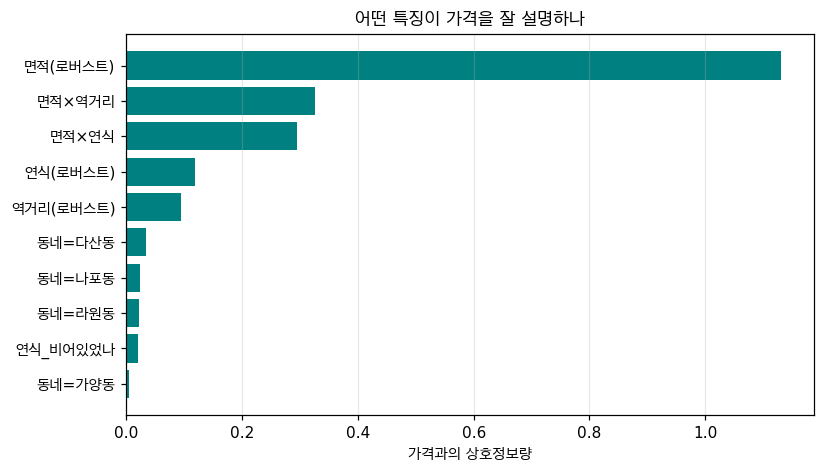

특징                               상호정보량
----------------------------------------
면적(로버스트)                       1.1312
면적×역거리                         0.3256
면적×연식                          0.2941
연식(로버스트)                       0.1182
역거리(로버스트)                      0.0941
동네=다산동                         0.0348
동네=나포동                         0.0240
동네=라원동                         0.0221
연식_비어있었나                       0.0197
동네=가양동                         0.0051

=> '연식_비어있었나' 열의 상호정보량이 거의 0입니다.
   이 데이터에서는 결측이 진짜 무작위로 뚫렸으니 당연합니다 (제가 그렇게 만들었죠).
   5절의 대출 데이터처럼 '결측이 정보인' 경우에는 이 값이 커집니다.
   💡 표시 열을 넣어 두고 상호정보량을 재 보면, '결측이 무작위인지' 알 수 있습니다.


In [28]:
# ✨ 추가 — 어떤 특징이 얼마나 중요했는지
p = 집특징파이프라인(상호작용=True, 선택개수=None).학습(원본훈련, 가격훈련)
A = p.적용(원본훈련)
MI = np.array([상호정보량(A[:, j], 가격훈련) for j in range(A.shape[1])])
이름들 = p.열이름()
순서 = np.argsort(MI)[::-1]

plt.figure(figsize=(7.6, 4.4))
plt.barh([이름들[j] for j in 순서][::-1], MI[순서][::-1], color="teal")
plt.xlabel("가격과의 상호정보량"); plt.title("어떤 특징이 가격을 잘 설명하나")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

print(f"{'특징':<26}{'상호정보량':>12}")
print("-" * 40)
for j in 순서:
    print(f"{이름들[j]:<25}{MI[j]:>12.4f}")
print(f"\n=> '연식_비어있었나' 열의 상호정보량이 거의 0입니다.")
print("   이 데이터에서는 결측이 진짜 무작위로 뚫렸으니 당연합니다 (제가 그렇게 만들었죠).")
print("   5절의 대출 데이터처럼 '결측이 정보인' 경우에는 이 값이 커집니다.")
print("   💡 표시 열을 넣어 두고 상호정보량을 재 보면, '결측이 무작위인지' 알 수 있습니다.")

---

## 9️⃣ 실무 — sklearn Pipeline과 ColumnTransformer

> 📗 **원문** — "Use It"
>
> 🔗 **앞 절과 이어서** — 8절에서 직접 조립해 봤습니다.
> 손으로 하면 **`학습`을 훈련 데이터에만 부르는 걸 사람이 기억해야** 합니다.
> 실수하면 3절에서 본 누출이 일어나죠. sklearn은 이걸 **구조적으로 막아 줍니다.**

```python
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, ["sqft", "age"]),
    ("cat", categorical_pipe, ["neighborhood"]),
])
```

### 🔑 `Pipeline`이 누출을 막는 원리

`pipeline.fit(X_train, y_train)`을 부르면 **안의 모든 변환기가 훈련 데이터로만 `fit`** 됩니다.
`pipeline.predict(X_test)`를 부르면 **`transform`만** 불립니다.

즉 **"실수로 전체 데이터에 fit 하는" 일이 구조적으로 불가능해집니다.**
교차검증과 같이 쓰면 **매 겹마다 전처리를 새로 `fit`** 해 주기까지 합니다.

> **9단원에서 이 이야기를 본격적으로 다룹니다.** 여기서는 맛만 봅니다.

In [29]:
# 📗 원문 Use It — sklearn 파이프라인
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_regression, VarianceThreshold

def 데이터프레임(원자료):
    return pd.DataFrame({"면적": 원자료["면적"], "연식": 원자료["연식"],
                         "역거리": 원자료["역거리"], "동네": 원자료["동네"]})

df훈련, df테스트 = 데이터프레임(원본훈련), 데이터프레임(원본테스트)

숫자칸 = ["면적", "연식", "역거리"]
범주칸 = ["동네"]

숫자관 = Pipeline([("채우기", SimpleImputer(strategy="median", add_indicator=True)),
                  ("스케일", StandardScaler())])
범주관 = Pipeline([("원핫", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))])
전처리 = ColumnTransformer([("숫자", 숫자관, 숫자칸), ("범주", 범주관, 범주칸)])

전체관 = Pipeline([("전처리", 전처리), ("모델", LinearRegression())])
전체관.fit(df훈련, 가격훈련)

print(f"sklearn 파이프라인 테스트 R² : {전체관.score(df테스트, 가격테스트):.4f}")
print(f"직접 만든 파이프라인(8절 ③)   : {점3:.4f}")
print(f"\n만들어진 특징 수: {전처리.fit_transform(df훈련).shape[1]}개")
print("=> 값이 비슷하면 같은 일을 한 겁니다. (로그 변환·상호작용은 안 넣었으니 조금 다릅니다)")

sklearn 파이프라인 테스트 R² : 0.9875
직접 만든 파이프라인(8절 ③)   : 0.9874

만들어진 특징 수: 8개
=> 값이 비슷하면 같은 일을 한 겁니다. (로그 변환·상호작용은 안 넣었으니 조금 다릅니다)


In [30]:
# ✨ 추가 — Pipeline이 누출을 막는 걸 직접 확인합니다
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest

# ⭐ 정보가 '완전히 0'인 데이터를 씁니다. 입력도 정답도 전부 무작위예요.
#    그러니 어떤 모델을 써도 진짜 실력은 정확히 50%여야 합니다
r = np.random.default_rng(0)
n행, n열 = 200, 2000
X무의미 = r.normal(size=(n행, n열))
y무의미 = r.integers(0, 2, n행)

# ❌ 잘못: 전체 데이터로 특징을 먼저 고르고, 그다음 교차검증
미리고름 = SelectKBest(k=20).fit(X무의미, y무의미)
나쁜점수 = float(np.mean(cross_val_score(LogisticRegression(max_iter=3000),
                                        미리고름.transform(X무의미), y무의미, cv=5)))

# ✅ 올바름: 특징 선택을 Pipeline에 넣어 매 겹마다 새로 고르게
좋은관 = Pipeline([("고르기", SelectKBest(k=20)),
                  ("모델", LogisticRegression(max_iter=3000))])
좋은점수 = float(np.mean(cross_val_score(좋은관, X무의미, y무의미, cv=5)))

print(f"입력 {n열}개 열, 정답 모두 무작위. 정보가 0입니다.")
print(f"=> 진짜 실력은 **정확히 50%** 여야 합니다 (동전 던지기와 같음)\n")
print(f"{'방법':<44}{'교차검증 점수':>14}")
print("-" * 60)
print(f"{'❌ 전체로 특징 고른 뒤 교차검증':<41}{나쁜점수:>15.1%}")
print(f"{'✅ Pipeline 안에서 겹마다 특징 고르기':<39}{좋은점수:>15.1%}")
print(f"{'(정답)':<45}{0.5:>14.1%}")

print(f"\n=> ❌ 쪽은 {나쁜점수:.1%}입니다. 정보가 0인 데이터에서 말이 안 되는 점수죠.")
print(f"   {n열}개 열 중 '우연히 정답과 맞는' 20개를 전체 데이터를 보고 골랐기 때문입니다.")
print(f"   그 '우연'이 검증 겹에서도 그대로 재현되니 점수가 부풀려집니다.")
print(f"\n   ✅ 쪽은 {좋은점수:.1%}로 50%에 훨씬 가깝습니다.")
print(f"   겹마다 훈련 부분만 보고 다시 고르니, 검증 겹의 우연을 이용할 수 없습니다.")
print(f"\n💡 전처리는 '모델의 일부'입니다. Pipeline에 넣으면 이 실수를 할 수가 없습니다.")
print("   ⚠️ 특징 선택뿐 아니라 스케일러·결측 채우기·타깃 인코딩 전부 마찬가지입니다.")
print("      9단원에서 이 이야기를 본격적으로 다룹니다.")

입력 2000개 열, 정답 모두 무작위. 정보가 0입니다.
=> 진짜 실력은 **정확히 50%** 여야 합니다 (동전 던지기와 같음)

방법                                                 교차검증 점수
------------------------------------------------------------
❌ 전체로 특징 고른 뒤 교차검증                                 75.5%
✅ Pipeline 안에서 겹마다 특징 고르기                        55.5%
(정답)                                                  50.0%

=> ❌ 쪽은 75.5%입니다. 정보가 0인 데이터에서 말이 안 되는 점수죠.
   2000개 열 중 '우연히 정답과 맞는' 20개를 전체 데이터를 보고 골랐기 때문입니다.
   그 '우연'이 검증 겹에서도 그대로 재현되니 점수가 부풀려집니다.

   ✅ 쪽은 55.5%로 50%에 훨씬 가깝습니다.
   겹마다 훈련 부분만 보고 다시 고르니, 검증 겹의 우연을 이용할 수 없습니다.

💡 전처리는 '모델의 일부'입니다. Pipeline에 넣으면 이 실수를 할 수가 없습니다.
   ⚠️ 특징 선택뿐 아니라 스케일러·결측 채우기·타깃 인코딩 전부 마찬가지입니다.
      9단원에서 이 이야기를 본격적으로 다룹니다.


---

## 🔟 용어 사전

> 📗 **원문** — "Key Terms" (설명은 쉬운 말로 다시 썼습니다)

| 용어 | 흔히 하는 말 | 진짜 무슨 뜻인가 |
| --- | --- | --- |
| **특징 공학** | "새 열 만들기" | 날데이터를 **모델이 무늬를 찾기 쉬운 형태**로 바꾸는 일 |
| **표준화** | "정규화하기" | 평균을 빼고 표준편차로 나눠 평균 0, 표준편차 1로 만드는 것 |
| **최소-최대 스케일링** | "0~1로 맞추기" | $(x-\min)/(\max-\min)$. **이상치 하나에 아주 약합니다** |
| **로버스트 스케일링** | "이상치에 강한 스케일링" | 중앙값과 IQR을 씁니다. 이상치가 있을 때 표준화보다 낫습니다 |
| **원핫 인코딩** | "더미 변수 만들기" | 범주마다 0/1 열 하나. 각 행에서 **정확히 하나만 1** |
| **라벨 인코딩** | "숫자로 바꾸기" | 범주를 정수로. **가짜 순서가 생겨서 트리 계열에만 적절** |
| **타깃 인코딩** | "정답으로 인코딩하기" | 범주를 그 범주의 **평균 목표값**으로 바꿈. **누출 위험이 가장 큼** |
| **TF-IDF** | "고급 단어 세기" | 단어 빈도 × 역문서빈도. **그 문서만의 특징적인 단어**에 큰 값 |
| **결측값 채우기** | "빈칸 메우기" | 빈 값을 추정값(평균·중앙값·최빈값)으로 대체. **표시 열도 같이 만드세요** |
| **특징 선택** | "쓸모없는 열 버리기" | 잡음이나 중복인 특징을 빼고 신호 있는 것만 남기기 |
| **상호정보량** | "얼마나 알려 주나" | $X$를 관찰해서 $Y$에 대한 불확실성이 얼마나 줄어드는가. **비선형도 잡음** |
| **데이터 누출** | "실수로 답을 봄" | 예측 시점에 없을 정보를 훈련에 쓰는 것. **점수가 거짓으로 좋아집니다** |

---

## ✅ 이 단원 요약 (6줄)

1. **특징이 모델보다 중요합니다.** 0절에서 모델 4종 교체보다 특징 하나 바꾸는 게 효과가 컸습니다.
2. **순서가 있습니다.** 결측 → 변환 → 상호작용 → 선택. 결측이 먼저여야 평균 계산이 깨지지 않습니다.
3. **스케일링은 이상치를 보고 고르세요.** 최소-최대는 이상치 하나에 무너집니다. 로버스트가 안전합니다.
4. **라벨 인코딩은 트리 계열에만.** 선형 모델은 가짜 순서를 곧이곧대로 믿습니다.
5. ⚠️ **타깃 인코딩은 정답을 써서 특징을 만듭니다.** 훈련 데이터만 보고 `fit` 하지 않으면 누출됩니다.
6. **잡음 특징은 과적합 재료입니다.** 좋은 특징 10개 + 잡음 90개는 좋은 특징 10개보다 나쁩니다.

> 💡 그리고 이 단원 전체를 관통하는 교훈: **"통념 대신 재서 결정하세요."**
> 로그 변환도(2절), 특징 선택도(8절) 항상 이기는 게 아니었습니다.

---

## 📝 연습문제

> 📗 **원문** — "Exercises" (전부 본문에서 풀었습니다)

1. **로버스트 스케일링**을 추가하고, 이상치가 심한 데이터에서 표준 스케일링과 비교하세요. → *2절에서 함*
2. **LOO 타깃 인코딩**을 구현하고, 순진한 타깃 인코딩보다 과적합이 줄어드는지 보이세요. → *3절에서 함*
3. **분산 임곗값 + 상관 필터 + 상호정보량**을 조합한 자동 선택 파이프라인을 만들고, 전체 특징 대비 성능을 비교하세요. → *7·8절에서 함*

### ✨ 추가 도전 과제

4. 4절 `TFIDF벡터`에 **n-그램**(두 단어 묶음)을 추가해 보세요. "머신 러닝"처럼 붙어야 의미가 생기는 말을 잡아내나요?
5. 3절 타깃 인코딩을 **K-겹 방식**으로 바꿔 보세요 (각 겹의 인코딩을 나머지 겹으로 계산). LOO와 비교하면 어떤가요?
6. 7절 `상호정보량`은 칸 개수(`칸수`)에 결과가 달라집니다. 칸을 4, 12, 50개로 바꿔 보고 순위가 얼마나 흔들리는지 확인하세요.
7. 6단원의 **차원의 저주**와 7절의 **특징 선택**을 이어 보세요. KNN에 잡음 열을 붙였을 때, 특징 선택으로 성능이 회복되나요?
8. 8절 파이프라인에 **다항 특징**(2절)을 추가해 보세요. R²가 오르나요, 떨어지나요? 떨어지면 왜일까요?

---

## 📚 더 읽을거리

> 📗 **원문** — "Further Reading"

- [Feature Engineering for Machine Learning (Zheng & Casari)](https://www.oreilly.com/library/view/feature-engineering-for/9781491953235/) — 특징 공학 전용 교과서
- [scikit-learn Preprocessing 문서](https://scikit-learn.org/stable/modules/preprocessing.html)
- [scikit-learn Feature Selection 문서](https://scikit-learn.org/stable/modules/feature_selection.html)
- [Kaggle: Feature Engineering 강의](https://www.kaggle.com/learn/feature-engineering) — 실전 예제 중심